#### **Machine Learning and Data Science Research Project - Research (Vectorized)**

**Project:** Reinforcement Learning for Optimal Execution - GPU Accelerated Version

**Author:** Robert de Witt (CID: 02541719)

**Note:** This is a vectorized version optimized for GPU acceleration and faster training.


In [1]:
import time                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
import pandas as pd
from notebook_logging_setup import quick_setup
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import VecNormalize
from tqdm import tqdm
import torch
import torch.nn as nn
import numpy as np
import random
import gc
import psutil

# my libraries
from mkt_data_mana import ManaMarketDataLoader as mmdl
import render_plots as rp
import model_parking as mp
from optimal_execution_env_vectorized import VectorizedMultiOrderExecutionEnv
from order_generator import OrderGenerator
from quote_and_trade_analytics import QuoteAndTradeAnalytics
import baseline_strategies as bs
import gpu_utils
from custom_tensorboard_callback import create_training_callbacks
from propagator_param_loader import PropagatorParamLoader
from cost_models import StandardExecutionCostModel
import ppo_optimizer as po


quick_setup(debug=False)
fixed_seed = 42
np.random.seed(fixed_seed)
random.seed(fixed_seed)  # Also seed the random module  

device = gpu_utils.get_torch_device()
gpu_utils.set_random_seed(fixed_seed)

print(f"Using device: {device}")
print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB" if device == 'cuda' else "")
print(f"MPS Available: {torch.backends.mps.is_available()}" if device == 'mps' else "")

# Vectorized environment configuration
max_trading_rate = 0.8
max_order_size_in_adv_pct = 0.1
num_vec_envs_gpu = 64 
num_vec_envs_cpu_train = 64
num_vec_envs_cpu_test = 512

print(f"Vectorized configuration:")
print(f"  - Num vectorized environments: GPU: {num_vec_envs_gpu} and CPU train: {num_vec_envs_cpu_train} and CPU test: {num_vec_envs_cpu_test}")
print(f"  - Device: {device}")
print(f"  - Max trading rate: {max_trading_rate}")
print(f"  - Max order size (ADV %): {max_order_size_in_adv_pct}")

2025-08-29 15:34:41.957086: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-29 15:34:41.966882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756478081.977871    4011 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756478081.980948    4011 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756478081.989392    4011 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Logging configured at INFO level
2025-08-29 15:34:44 - root - INFO - Using CUDA GPU: NVIDIA GeForce RTX 4090
2025-08-29 15:34:44 - root - INFO - CUDA Device Count: 1
2025-08-29 15:34:44 - root - INFO - Current CUDA Device: 0
Using device: cuda
GPU Memory Available: 24.0 GB

Vectorized configuration:
  - Num vectorized environments: GPU: 64 and CPU train: 64 and CPU test: 512
  - Device: cuda
  - Max trading rate: 0.8
  - Max order size (ADV %): 0.1


In [3]:
# Stock selection - optimized for vectorized processing
tickers = None
#tickers = ['MSFT','GOOGL']

# Load market data with progress tracking
print("\nLoading market data...")
start_time = time.time()
md = mmdl(load_data=True)
load_time = time.time() - start_time
print(f"Data loaded in {load_time:.2f} seconds")

# Check available dates
print(f"Available dates: {md.start_date} to {md.end_date}")


all_stock_list = md.all_stock_list                                                      

if tickers is None:
    tickers = all_stock_list

# Check available symbols, wrap 15 symbols per row
print(f"Available symbols sample[0:15], total {len(all_stock_list)}:")
print(f"[(1:15)]{all_stock_list[0:15]},")

# get dataframe with market data
processing_time = time.time() - start_time
print(f"Data finished processing in {processing_time:.2f} seconds")


Loading market data...
Data loaded in 1.50 seconds
Available dates: 2022-01-03 to 2022-12-30
Available symbols sample[0:15], total 402:
[(1:15)]['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP'],
Data finished processing in 15.38 seconds


In [4]:
# Create train/test split using date filtering with larger batches for vectorized processing
start_time = time.time()

train_stock_df_list = md.to_pandas_dict_fast(start_pct=0.0, end_pct=0.7)
test_stock_df_list = md.to_pandas_dict_fast(start_pct=0.71, end_pct=1.0)
print(f"to_pandas_dict time: {time.time() - start_time:0.2f} seconds")
print(f"train_stock_df_list: {train_stock_df_list.keys()}")
# print head of train_stock_df_list in a nicer format, show all columns in one line
print(f"train_stock_df_list: {train_stock_df_list[tickers[0]].head(2).to_string(index=False)}")
print(f"train_stock_df_list: {train_stock_df_list[tickers[1]].head(2).to_string(index=False)}")
print(f"train_stock_df_list time: {time.time() - start_time:0.2f} seconds")

2025-08-29 15:35:31 - mkt_data_mana - INFO - start_date: 2022-01-03, end_date: 2022-09-13, num_dates: 165
2025-08-29 15:35:31 - mkt_data_mana - INFO - Loaded data for 393 symbols: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM']...
2025-08-29 15:35:49 - mkt_data_mana - INFO - start_date: 2022-09-16, end_date: 2022-12-30, num_dates: 71
2025-08-29 15:35:49 - mkt_data_mana - INFO - Loaded data for 394 symbols: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI']...
to_pandas_dict time: 44.68 seconds
train_stock_df_list: dict_keys(['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'ATVI', 'AVB', 'AVGO', 'AWK', 'AXP', 'BA', 'BALL', 'BAX', 'BBWI', 'BBY', 'BDX', 'BEN', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLK', 'BMY', 'BRO', 'BWA', 'BX

**Order Generation**

The order generation process creates a set of trading orders with the following characteristics:
1.  For each order, a random stock is selected from the available universe, and its Average Daily Volume (ADV) is calculated as the mean of daily trading volumes.
2. The order size is determined by sampling a random percentage of ADV between min_adv_pct and max_adv_pct, scaled by the time horizon (as a fraction of the trading day). This ensures that larger orders are spread over longer time periods and that the orders can complete within the time horizon given 
3. The execution window is defined by randomly selecting a start time and a time horizon (in minutes) between min_time_horizon and max_time_horizon, with the end time being start_time + time_horizon.
4. Each order is assigned a random side (buy/sell) and its quantity is rounded to the nearest integer, with safeguards to prevent zero-sized orders. The resulting orders are then used to train or evaluate the execution strategy in the reinforcement learning environment.
5. For simplicity's sake, we will not apply order constraints such as limit prices or volume limits, we will assume lit market trading only and we will not worry about auctions.

In [5]:
print("Generating training orders...")
import importlib
import order_generator 
import propagator_param_loader

importlib.reload(order_generator)
importlib.reload(propagator_param_loader)

from order_generator import OrderGenerator
from propagator_param_loader import PropagatorParamLoader

loader = PropagatorParamLoader("mana_data/propagator_model_data_cross_validation")

# TODO: make more robust to use max days symbol not just the random symbol in [0]
train_date_range = OrderGenerator.get_dates_from_dataframe(train_stock_df_list[tickers[0]])
test_date_range = OrderGenerator.get_dates_from_dataframe(test_stock_df_list[tickers[0]])

print(f"Train date range: {train_date_range[0]} to {train_date_range[-1]}")
print(f"Test date range: {test_date_range[0]} to {test_date_range[-1]}")

# load daily mana analytics
daily_analytics = QuoteAndTradeAnalytics(symbols=tickers)

train_orders_df = OrderGenerator(
    stock_df_list=train_stock_df_list,
    md_source='mana',
    market_data=md, 
    debug=False,
    dates=train_date_range,
    analytics=daily_analytics,
    max_adv_pct=max_order_size_in_adv_pct, 
    propagator_loader=loader,
    num_orders=25000,
    y_column='Y_best',
    tau_column='tau_best',
    seed=fixed_seed
).get_orders()

train_time = time.time() - start_time
print(f"Training orders generated in {train_time:.2f} seconds")

print("Generating test orders...")
start_time = time.time()

# Test set: last 2 days (exclude first 5 days) - larger batch for vectorized processing
test_orders_df = OrderGenerator(
    stock_df_list=test_stock_df_list,
    md_source='mana',
    market_data=md, 
    debug=False,
    dates=test_date_range,
    analytics=daily_analytics,
    max_adv_pct=max_order_size_in_adv_pct, 
    propagator_loader=loader,
    num_orders=25000,
    y_column='Y_best',
    tau_column='tau_best',
    seed=fixed_seed
).get_orders()

test_time = time.time() - start_time
print(f"Test orders generated in {test_time:.2f} seconds")

# Verify the date split
print(f"\nTrain set: {len(train_orders_df)} orders")
print(f"Train dates: {train_orders_df['date'].min()} to {train_orders_df['date'].max()}")
#print(f"Orders per day (train):\n{train_orders_df['date'].value_counts().sort_index()}")

print(f"\nTest set: {len(test_orders_df)} orders")
print(f"Test dates: {test_orders_df['date'].min()} to {test_orders_df['date'].max()}")
#print(f"Orders per day (test):\n{test_orders_df['date'].value_counts().sort_index()}")

train_idx = pd.DatetimeIndex(train_date_range)
test_idx  = pd.DatetimeIndex(test_date_range)

# Verify no overlap
print(f"No overlap verified: {len(train_idx.intersection(test_idx)) == 0}")


Generating training orders...
2025-08-29 15:35:51 - propagator_param_loader - INFO - PropagatorParamLoader initialized with 388 symbols
Train date range: 2022-01-03 to 2022-09-13
Test date range: 2022-09-16 to 2022-12-30
2025-08-29 15:35:51 - quote_and_trade_analytics - INFO - Loading analytics from: mana_data/daily_analytics_parquet
2025-08-29 15:35:51 - quote_and_trade_analytics - INFO - Found 402 symbol directories
2025-08-29 15:38:10 - quote_and_trade_analytics - INFO - Successfully loaded analytics for 402 symbols
2025-08-29 15:38:10 - quote_and_trade_analytics - INFO - Available analytics columns: ['symbol', 'adv_21_days', 'avg_trade_count_21_days', 'avg_spread_21_days', 'avg_depth_21_days', 'vwap', 'daily_volatility', 'daily_volatility_lag1', 'daily_volatility_5d']
2025-08-29 15:38:10 - order_generator - INFO - Generating 25000 orders for 393 stocks across 165 dates
2025-08-29 15:38:10 - order_generator - INFO - Date range: 2022-01-03 to 2022-09-13
2025-08-29 15:38:10 - order_ge

3 Sample Train Orders:
Sample Train (1): ticker: CDNS order_qty: 23878 adv_pct: 4.39% ehv_pct: 4.92% adv: 543,746 date: 2022-08-23 start_time: 27 end_time: 376 time_horizon: 349 side: sell avg_spread_21_days: 0.000427354881213387 avg_depth_21_days: 148.11186327253068 daily_volatility: 0.009926867338538068 daily_volatility_lag1: 0.009182222757050293 daily_volatility_5d: 0.008447564345394986 daily_vwap: 183.9737548828125 intra_order_return: 0.005463120993226767 adv_21_days: 543746.4761904762 avg_trade_count_21_days: 22116.714285714286 Y: 0.00025143711030619937 tau: 5.951784664324062 r2: 0.027434663334287186 
Sample Train (2): ticker: ATO order_qty: 301 adv_pct: 0.07% ehv_pct: 2.09% adv: 401,403 date: 2022-09-06 start_time: 213 end_time: 227 time_horizon: 14 side: buy avg_spread_21_days: 0.000409515596338677 avg_depth_21_days: 228.56655956449964 daily_volatility: 0.01190302178122914 daily_volatility_lag1: 0.011913329534656448 daily_volatility_5d: 0.011617426783721529 daily_vwap: 114.94061

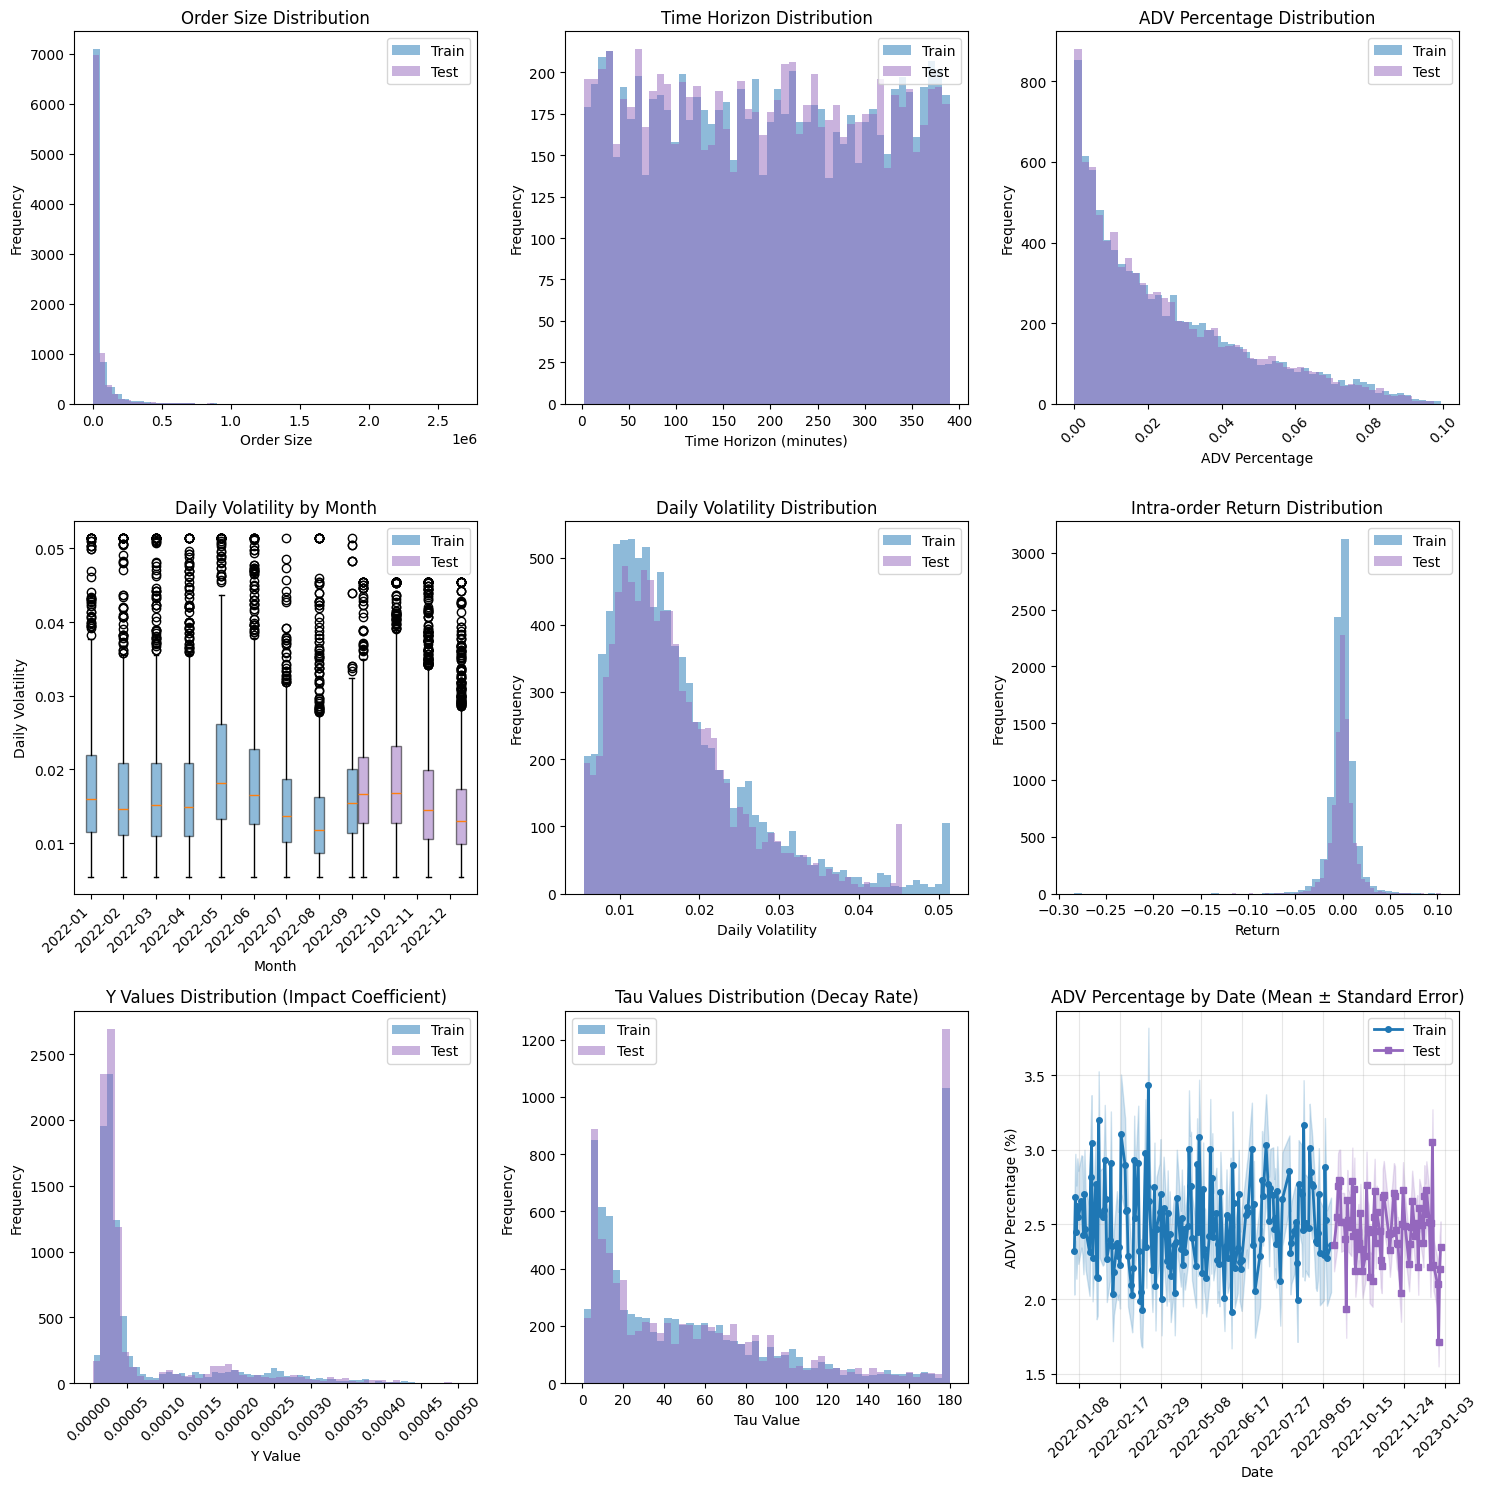


Sample train orders with dates:
  ticker        date  start_time  end_time  order_qty  side
0   CDNS  2022-08-23          27       376      23878  sell
1    ATO  2022-09-06         213       227        301   buy
2   CTVA  2022-05-10          70       177      33669   buy
3    ADP  2022-02-23         252       390       1519   buy
4   DXCM  2022-07-25         187       307      16907   buy

Sample test orders with dates:
  ticker        date  start_time  end_time  order_qty  side
0    TGT  2022-12-05          81       351      56951  sell
1   CHTR  2022-10-27          69       219      16827   buy
2    RCL  2022-11-09         127       134       1004   buy
3    RSG  2022-10-03          16       185       7833  sell
4   COST  2022-12-05         112       122       1301  sell


In [ ]:
import importlib
import render_plots as rp

importlib.reload(rp)

# print orders dataframe in single line per order
rp.display_order_info(train_orders_df, name='Sample Train', num_orders=3)
rp.display_order_info(test_orders_df, name='Sample Test', num_orders=3)
rp.plot_order_histograms(train_orders_df, test_orders_df)

# Show sample orders with dates
print("\nSample train orders with dates:")
print(train_orders_df[['ticker', 'date', 'start_time', 'end_time', 'order_qty', 'side']].head(5))
print("\nSample test orders with dates:")
print(test_orders_df[['ticker', 'date', 'start_time', 'end_time', 'order_qty', 'side']].head(5))


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        **RL Environment**

In the current setup the agent’s **state** at each step is a 14-dimensional real vector  
$$
s_t = \bigl[p_t^{\rm mid},\,V_t,\,T - t,\,q_t,\,\alpha,\,x,\,f,\,m,\,\delta,\,A,\,p_0,\,r,\,v^{(1)},\,v^{(5)}\bigr],
$$  
where it sees the current mid-price, market volume, time and shares remaining, target participation rate, trading signals, last fill and trade stats, arrival price, regime and short/long‐term volatilities.  Its **action**  
$$
a_t \in \{-1.0,\,-0.75,\, -0.5,\,-0.25,\,-0.1,\,0,\,0.10,\,0.15,\,0.25,\,0.50,\,0.75,\ 1.0\}
$$  
is “accelerate or decelerate versus the constant rate to trade this fraction of today’s volume,” so the env executes  
$$
\Delta q_t = \min(\rho_i(1 + a_t)\,V_t,\;q_t)
$$  
shares (and updates  
$$
q_{t+1} = q_t - \Delta q_t
$$  

$$\rho_i = \frac{Q_i}{V[t_{start}, t_{end}]}$$ 
and the running VWAP).  Episodes end when either all shares are filled or the time horizon is hit, a large penalty is applied if the order does not complete.


**Trading Simulation**

In order to realistically simulate market behaviour, each trade needs to create an impact on price, and successive trades must propagate impact to the next order and so on. Rather than consider the nuance of trade by trade, limit and market orders and order books which require many assumptions and complex limit order book simulators, we focus on minutely percentage of volume trading. This allows to focus on building an optimal scheduling algorithm and removes the granular complexities of limit order books, order types and venue types.

For minutely impact level impact estimations have utilized the transient impact model 2 from Bouchaud's book Trades, Quotes and Prices [7] which is parameterized with intuitive default values for this update and assumes the 1 minute trade impact follows square root.  We account for gaps between 1 minute trade intervals allowing for more accurate decay. In the final report, we will include a calibrated version of this model based on the trades observed via Bank of America's trade data. 


**Linear Transient‐Impact (Propagator) Model [7]**  
$$
r_t \;=\;\sum_{t'<t} G(t - t')\,\epsilon_{t'} \;+\;\eta_t,
$$
where $r_t = P_t - P_{t-1}$ is the mid-price return, $\epsilon_{t'}\!=\pm1$ the sign of the trade at time $t'$, $G(\tau)$ the propagator kernel, and $\eta_t$ an uncorrelated noise term.  

In our case we do allow for non-uniformity of time steps between trades so we modify to consider the $t_{\Delta}$:

$$
\lambda(\Delta t)
\;=\;
\exp\!\Bigl(-\frac{\Delta t}{\tau}\Bigr),
\quad
\Delta I_t
\;=\;
Y\,\sigma\,\sqrt{\frac{q_t}{V}},
$$

$$
I_t
\;=\;
\lambda(\Delta t)\,I_{t-1}
\;+\;
\Delta I_t,
$$

$$
p_t^{\mathrm{fill}}
\;=\;
p_t^{\mathrm{vwap}}
\bigl(1 \;+\; s\,I_t\bigr).
$$

In [6]:
# Create vectorized execution environments for training
print("Creating vectorized training environment...")
import importlib
import optimal_execution_env_vectorized as oeev
import cost_models
importlib.reload(oeev)
importlib.reload(cost_models)
from cost_models import StandardExecutionCostModel

rl_cost_model = StandardExecutionCostModel()
PPO_GAMMA = 0.999  

print("Creating CPU training environment...")

# Use the new vectorized environment with wrapper for training
train_execution_cpu_env = oeev.VectorizedMultiOrderExecutionEnv(
    stock_df_list=train_stock_df_list,
    orders_df=train_orders_df,
    impact_coef=1,
    decay_rate=5,
    num_envs=num_vec_envs_cpu_train,  
    min_rate=0,
    max_rate=max_trading_rate,
    device='cpu',
    seed=fixed_seed,
    cost_model=rl_cost_model
)

train_execution_cpu_env = VecNormalize(
    train_execution_cpu_env,
    norm_obs=True, norm_reward=True,
    clip_obs=10., clip_reward=10.,
    gamma=PPO_GAMMA,   
)

# Check environment
print("OK: Vectorized cpu train environment loaded!")

# Create vectorized execution environments for testing (direct access for execution)
print("\nCreating vectorized cpu test environment...")


# for compatibility with training environment, create a GPU (if available) and CPU environment
if device in ["cuda", "mps"]:

    print("Initializing VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training")

    train_execution_gpu_env = oeev.VectorizedMultiOrderExecutionEnv(
        stock_df_list=train_stock_df_list,
        orders_df=train_orders_df,
        impact_coef=1,
        decay_rate=5,
        num_envs=num_vec_envs_gpu,  
        min_rate=0,
        max_rate=max_trading_rate,
        device=device,
        seed=fixed_seed
    )

    train_execution_gpu_env = VecNormalize(
        train_execution_gpu_env,
        norm_obs=True, norm_reward=True,
        clip_obs=10., clip_reward=10.,
        gamma=PPO_GAMMA,   
    )   

    print("OK: VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training loaded!")


else:
    print("No GPU available, using CPU for training and testing")
    train_execution_gpu_env = train_execution_cpu_env


print(f"\nVectorized Environment Summary:")
print(f"  - Training orders: {len(train_orders_df)}")
print(f"  - Test orders: {len(test_orders_df)}")
print(f"  - Vectorized environments: GPU: {num_vec_envs_gpu} and CPU train: {num_vec_envs_cpu_train} and CPU test: {num_vec_envs_cpu_test}")
if device in ["cuda", "mps"]:
    print(f"  - Device: {device} + CPU")
else:
    print(f"  - Device: cpu")


Creating vectorized training environment...
Creating CPU training environment...
2025-08-29 15:43:51 - optimal_execution_env_vectorized - INFO - Using device: cpu (explicitly set)
OK: Vectorized cpu train environment loaded!

Creating vectorized cpu test environment...
Initializing VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training
2025-08-29 15:43:54 - optimal_execution_env_vectorized - INFO - Using device: cuda (explicitly set)
OK: VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training loaded!

Vectorized Environment Summary:
  - Training orders: 25000
  - Test orders: 25000
  - Vectorized environments: GPU: 64 and CPU train: 64 and CPU test: 512
  - Device: cuda + CPU


In [7]:

# Set up environment for RL training 

importlib.reload(mp)
import ppo_optimizer as po
importlib.reload(po)


# Set up vectorized model parking and train a simple model
mp_vec = mp.ModelParking()

callbacks = create_training_callbacks(
    enable_custom=True,      # Enable custom TensorBoard logging
    enable_env_stats=True,   # Enable environment-specific stats
    enable_debug=False,      # Disable debug logging (can be verbose)
    verbose=0
)

num_orders_per_episode = 25000
num_train_steps = 390/2 * num_orders_per_episode

# Memory cleanup before training
if device != 'cpu':
    torch.cuda.empty_cache() if device == 'cuda' else None
    gc.collect()
    print("GPU memory cleaned")



2025-08-29 15:44:12 - root - INFO - ModelParking initialized without cached models.
GPU memory cleaned


In [8]:
# Train a simple vectorized PPO model
model_name = "ppo_multiorder_exec_vec"
print(f"\nTraining model: {model_name}")
start_time = time.time()

policy_kwargs = dict(
    features_extractor_kwargs=dict(features_dim=256),
    net_arch=dict(pi=[256, 256], vf=[256, 256]), 
    activation_fn=torch.nn.ReLU
    )

po.train_ppo_fast(train_execution_cpu_env, model_name, num_train_steps, callbacks=callbacks, 
               mp_vec=mp_vec, ppo_kwargs=policy_kwargs, device="cpu", ppo_gamma=PPO_GAMMA)



Training model: ppo_multiorder_exec_vec

OPTIMIZED PPO TRAINING: ppo_multiorder_exec_vec
Using cpu device
2025-08-29 15:44:20 - root - INFO - 
Optimized Training Configuration for ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3:
2025-08-29 15:44:20 - root - INFO -   - Parallel environments: 64
2025-08-29 15:44:20 - root - INFO -   - Steps per rollout: 2048
2025-08-29 15:44:20 - root - INFO -   - Total samples per rollout: 131,072
2025-08-29 15:44:20 - root - INFO -   - Batch size: 8,192
2025-08-29 15:44:20 - root - INFO -   - Mini-batches per epoch: 16
2025-08-29 15:44:20 - root - INFO -   - Epochs per update: 3
2025-08-29 15:44:20 - root - INFO -   - Approximate updates per second: 20.8
optimizer lr at init: 0.0003

Training ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3 for 4,875,000.0 timesteps...
Using 16 CPU threads for training
Logging to ./tensorboard_logs/ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3/PPO_9
--------------------------------

(<stable_baselines3.ppo.ppo.PPO at 0x7b05802bcd70>, 1618.6077105998993)

In [10]:
# Add baseline strategies
baseline_strategies = []
print("\nSetting up baseline strategies...")
vwap_model = bs.VWAPBaseline()
mp_vec.park_model(vwap_model, "vwap_baseline_vec", learn=False, save=False)
baseline_strategies.append("vwap_baseline_vec")
random_model = bs.RandomBaseline(seed=fixed_seed)
mp_vec.park_model(random_model, "random_baseline_vec", learn=False, save=False)
baseline_strategies.append("random_baseline_vec")
print(f"Baseline models saved")


Setting up baseline strategies...
2025-08-29 16:42:03 - baseline_strategies - INFO - Initialized VWAP_Baseline strategy
2025-08-29 16:42:03 - baseline_strategies - INFO - Initialized Random_Baseline strategy
Baseline models saved


In [9]:

model_name = "ppo_cnn_multiorder_exec_vec_cpu"

class ExecCNNExtractor(BaseFeaturesExtractor):
    """
    CNN-based feature extractor for execution states.

    Suitable when the state is represented as a structured 2D tensor
    (e.g. [channels x timesteps] for stacked time series of prices, spreads, volumes).
    """
    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)

        n_input_channels = observation_space.shape[0]

        # CNN backbone
        self.cnn = nn.Sequential(
            nn.Conv1d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),  # downsample time dimension

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # global pooling over time
        )

        # Linear projection to features_dim
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, features_dim),
            nn.ReLU()
        )

        self._features_dim = features_dim

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        # Expect obs: [batch_size, channels, timesteps]
        x = self.cnn(obs)
        return self.fc(x)


po.train_ppo_fast(train_execution_cpu_env, model_name=model_name, num_train_steps=num_train_steps,
                    mp_vec=mp_vec, feature_extractor=ExecCNNExtractor, callbacks=callbacks, 
                    device="cpu", ppo_gamma=PPO_GAMMA)



OPTIMIZED PPO TRAINING: ppo_cnn_multiorder_exec_vec_cpu
Using cpu device
2025-08-29 16:14:21 - root - INFO - 
Optimized Training Configuration for ppo_cnn_multiorder_exec_vec_cpu_nsteps_2048_batchsize_8192_epochs_3:
2025-08-29 16:14:21 - root - INFO -   - Parallel environments: 64
2025-08-29 16:14:21 - root - INFO -   - Steps per rollout: 2048
2025-08-29 16:14:21 - root - INFO -   - Total samples per rollout: 131,072
2025-08-29 16:14:21 - root - INFO -   - Batch size: 8,192
2025-08-29 16:14:21 - root - INFO -   - Mini-batches per epoch: 16
2025-08-29 16:14:21 - root - INFO -   - Epochs per update: 3
2025-08-29 16:14:21 - root - INFO -   - Approximate updates per second: 20.8
optimizer lr at init: 0.0003

Training ppo_cnn_multiorder_exec_vec_cpu_nsteps_2048_batchsize_8192_epochs_3 for 4,875,000.0 timesteps...
Using 16 CPU threads for training
2025-08-29 16:14:21 - optimal_execution_env_vectorized - WARNING - Found 2 NaN or non-positive Y values, replacing with median 3.3296663292894325

(<stable_baselines3.ppo.ppo.PPO at 0x7b03573f22d0>, 1661.6520771980286)

In [11]:
import map_elites_models as mem
import optimal_execution_env_vectorized as oeev
importlib.reload(mem)
importlib.reload(oeev)
import map_elites_models as mem
import optimal_execution_env_vectorized as oeev

mem_train_execution_cpu_env = oeev.VectorizedMultiOrderExecutionEnv(
    stock_df_list=train_stock_df_list,
    orders_df=train_orders_df,
    impact_coef=1,
    decay_rate=5,
    num_envs=128,  
    min_rate=0,
    max_rate=max_trading_rate,
    device='cpu',
    seed=fixed_seed,
    cost_model=rl_cost_model
)


archive = mem.map_elites(
    train_execution_cpu_env,
    init_policies=256,          # 128–256 sweet spot
    iters=60,                   # 30–60 if you’ve got time
    eval_orders_per_policy=5,   # 3 for speed, 5 for stability
    mutate_sigma=0.04,
    device="cpu",
    show_progress=False
)


2025-08-28 21:18:39 - optimal_execution_env_vectorized - INFO - Using device: cpu (explicitly set)


MAP-Elites: seeding:  24%|██▍       | 62/256 [01:18<04:45,  1.47s/it]

2025-08-28 21:20:01 - optimal_execution_env_vectorized - WARNING - Found 60 NaN or non-positive Y values, replacing with median 5.261182450626857e-05


MAP-Elites: seeding:  25%|██▍       | 63/256 [01:20<04:21,  1.35s/it]

2025-08-28 21:20:02 - optimal_execution_env_vectorized - WARNING - Found 60 NaN or non-positive Y values, replacing with median 8.996471830535757e-05


...

MAP-Elites: iterations:  78%|███████▊  | 47/60 [15:40<04:53, 22.58s/it]

2025-08-28 21:40:03 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive Y values, replacing with median 4.0517154759229966e-05


MAP-Elites: iterations:  83%|████████▎ | 50/60 [16:58<04:08, 24.81s/it]

2025-08-28 21:41:21 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive Y values, replacing with median 0.00016998273614769017


MAP-Elites: iterations: 100%|██████████| 60/60 [21:33<00:00, 21.56s/it]


In [12]:
best = archive.best()
print("Best fitness:", best["fitness"], "desc:", best["desc"])  

# Test the elite policy
elite_policy = best["policy"]
num_test_orders = 5000   
test_idxs = mem_train_execution_cpu_env.generate_random_order_indices(num_test_orders)
orders = mem_train_execution_cpu_env.execute_orders_vectorized(elite_policy, test_idxs, collect_step_info=True)
print(f"Mean total cost ({num_test_orders} orders):", np.mean([
    sum([s.get("total_step_cost", 0.0) for s in tr]) if any("total_step_cost" in s for s in tr) else tr[-1].get("total_cost", 0.0)
    for tr in orders if tr
]))

Best fitness: -0.009804063521005445 desc: (1.0, 0.8049563419754484)


  Executing 5000 orders:  10%|█         | 512/5000 orders [00:31<05:04]

2025-08-28 21:46:04 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive Y values, replacing with median 3.070410681689021e-05
2025-08-28 21:46:04 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive tau values, replacing with median 48.53804924083881


  Executing 5000 orders:  13%|█▎        | 640/5000 orders [00:40<05:01]

2025-08-28 21:46:13 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive Y values, replacing with median 3.208542884938155e-05


...

  Executing 5000 orders:  84%|████████▍ | 4224/5000 orders [05:23<01:01]

2025-08-28 21:50:56 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive Y values, replacing with median 3.506514025739919e-05


  Executing 5000 orders: 100%|█████████▉| 4992/5000 orders [06:26<00:00]

2025-08-28 21:51:59 - optimal_execution_env_vectorized - WARNING - Found 1 NaN or non-positive Y values, replacing with median 3.106446074220633e-05


Mean total cost (5000 orders): 0.039716086438503696


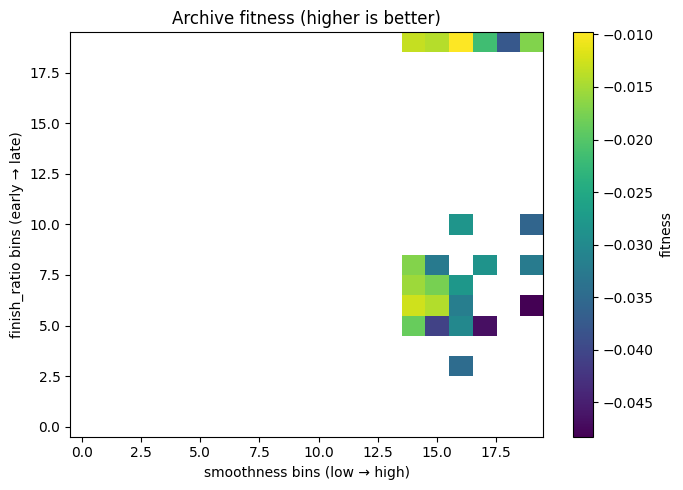

In [13]:
import optimal_execution_env_vectorized as oeev
importlib.reload(mem)
importlib.reload(oeev)
import map_elites_models as mem
import optimal_execution_env_vectorized as oeev
from map_elites_models import plot_archive_heatmap, select_elites

plot_archive_heatmap(archive)
best_overall = archive.best()
top_vwapish = select_elites(archive, finish_range=(0.45, 0.55), smooth_range=(0.7, 1.0), top_k=3)
top_front = select_elites(archive, finish_range=(0.0, 0.40), smooth_range=(0.6, 1.0), top_k=3)

In [ ]:
from tqdm import tqdm

import importlib
import cost_models as cm
importlib.reload(cm)
import cost_models as cm

import optimal_execution_env_vectorized as oeev
importlib.reload(oeev)
import optimal_execution_env_vectorized as oeev

test_execution_cpu_env = oeev.VectorizedMultiOrderExecutionEnv(
    stock_df_list=test_stock_df_list,
    orders_df=test_orders_df,
    impact_coef=1,
    decay_rate=5,
    num_envs=num_vec_envs_cpu_test,  
    min_rate=0,
    max_rate=max_trading_rate,
    device='cpu',
    seed=fixed_seed,
    cost_model=rl_cost_model
)

print("OK: Vectorized cpu test environment loaded!")

if device in ["cuda", "mps"]:

    print("OK: VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training loaded!")

    # Create vectorized execution environments for testing (direct access for execution)
    print("\nCreating vectorized gpu test environment...")
 
    test_execution_gpu_env = oeev.VectorizedMultiOrderExecutionEnv(
        stock_df_list=test_stock_df_list,
        orders_df=test_orders_df,
        impact_coef=1,
        decay_rate=5,
        num_envs=num_vec_envs_gpu,  
        min_rate=0,
        max_rate=max_trading_rate,
        device=device,
        seed=fixed_seed
    )
    
    print("OK: Vectorized gpu test environment check loaded!")

else:
    print("No GPU available, using CPU for training and testing")
    train_execution_gpu_env = train_execution_cpu_env
    test_execution_gpu_env = test_execution_cpu_env



print("="*80)
print("All models will execute the same orders")
print("="*80)

model_name_list = mp_vec.list_models()
print(f"Available models: {model_name_list}")

num_episodes = 15000  
execution_times = {}
test_orders = {}

print(f"All {len(model_name_list)} models will execute the same {num_episodes} orders for fair comparison.")
print("="*80)

# Manual consistent comparison approach
common_order_indices = None
i = 0

base_cpu_env = test_execution_cpu_env.venv if isinstance(test_execution_cpu_env, VecNormalize) else test_execution_cpu_env
common_order_indices = base_cpu_env.generate_random_order_indices(num_episodes) 
print(f"Using order indices: {common_order_indices[:5]}...{common_order_indices[-5:]} (showing first/last 5)")

# support with tqdm 
for i, model_name in enumerate(tqdm(model_name_list, desc="Executing models", leave=False)):

    model = mp_vec.get_model(model_name)
    
    # if device attribute exists and is in ["cuda", "mps"] then use the gpu environment
    # otherwise use the cpu environment
    if model_name in baseline_strategies:
        eval_execution_env = test_execution_cpu_env
        model.device = "cpu"
    else:
        if hasattr(model, 'device') and model.device in ["cuda", "mps"]:
            print(f"Using GPU environment for {model_name}")
            eval_execution_env = mp_vec.load_vecnorm(model_name, test_execution_gpu_env)
        else:
            print(f"Using CPU environment for {model_name}")
            # filter out baseline strategies
            eval_execution_env = mp_vec.load_vecnorm(model_name, test_execution_cpu_env)
            model.device = "cpu"

    print(f"\n{'='*60}")
    print(f"Executing orders with model: {model_name} with device: {model.device} ({i+1}/{len(model_name_list)})")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    env_for_exec = eval_execution_env.venv if isinstance(eval_execution_env, VecNormalize) else eval_execution_env
    
    if isinstance(eval_execution_env, VecNormalize):
        eval_execution_env.training = False
        eval_execution_env.norm_reward = False
    
    orders = env_for_exec.execute_orders_vectorized(
        model=model,
        order_indices=common_order_indices,
        collect_step_info=True, 
        show_progress=True,
        
        )
    
    test_orders[model_name] = orders
    
    exec_time = time.time() - start_time
    execution_times[model_name] = exec_time
    
    print(f"Execution completed in {exec_time:.2f} seconds")
    print(f"Average time per episode: {exec_time/num_episodes:.3f} seconds")
    
    # Memory cleanup between models
    if hasattr(model, 'device') and model.device in ["cuda", "mps"]:
        if test_execution_env.device == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()


print(f"\nEXECUTION COMPLETED!")
if common_order_indices is not None:
    print(f"All {len(model_name_list)} models executed the same {len(common_order_indices)} orders for fair comparison!")
    print(f"Order indices used: {common_order_indices}")
else:
    print("Using fallback method - orders may not be identical across models.")
    print("Consider checking the implementation of execute_orders method.")

print(f"\n{'='*60}")
print("VECTORIZED EXECUTION SUMMARY")
print(f"{'='*60}")
total_time = sum(execution_times.values())
for model_name, exec_time in execution_times.items():
    print(f"{model_name:30}: {exec_time:6.2f}s ({exec_time/num_episodes:.3f}s/episode)")
print(f"{'Total execution time':30}: {total_time:6.2f}s")
print(f"{'Average per model':30}: {total_time/len(execution_times):6.2f}s")


2025-08-29 16:42:03 - optimal_execution_env_vectorized - INFO - Using device: cpu (explicitly set)
OK: Vectorized cpu test environment loaded!
OK: VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training loaded!

Creating vectorized gpu test environment...
2025-08-29 16:42:04 - optimal_execution_env_vectorized - INFO - Using device: cuda (explicitly set)
OK: Vectorized gpu test environment check loaded!
All models will execute the same orders
Available models: ['ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3', 'ppo_cnn_multiorder_exec_vec_cpu_nsteps_2048_batchsize_8192_epochs_3', 'vwap_baseline_vec', 'random_baseline_vec']
All 4 models will execute the same 15000 orders for fair comparison.
Using order indices: [6868, 24016, 9668, 13640, 14018]...[18468, 5914, 456, 16076, 21417] (showing first/last 5)


Executing models:   0%|          | 0/4 [00:00<?, ?it/s]

Using CPU environment for ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3

Executing orders with model: ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3 with device: cpu (1/4)


2025-08-29 16:42:06 - optimal_execution_env_vectorized - WARNING - Found 18 NaN or non-positive Y values, replacing with median 3.054011659363926e-05
2025-08-29 16:42:06 - optimal_execution_env_vectorized - WARNING - Found 18 NaN or non-positive tau values, replacing with median 50.09962148096464


2025-08-29 16:43:17 - optimal_execution_env_vectorized - WARNING - Found 26 NaN or non-positive Y values, replacing with median 3.043422437326789e-05


...

2025-08-29 18:15:56 - optimal_execution_env_vectorized - WARNING - Found 21 NaN or non-positive Y values, replacing with median 3.091559396768744e-05


2025-08-29 18:16:21 - optimal_execution_env_vectorized - WARNING - Found 15 NaN or non-positive Y values, replacing with median 3.0138226928420884e-05


2025-08-29 18:16:46 - optimal_execution_env_vectorized - WARNING - Found 23 NaN or non-positive Y values, replacing with median 3.0181621173595926e-05


2025-08-29 18:17:10 - optimal_execution_env_vectorized - WARNING - Found 15 NaN or non-positive Y values, replacing with median 3.0176309489128556e-05


2025-08-29 18:17:34 - optimal_execution_env_vectorized - WARNING - Found 16 NaN or non-positive Y values, replacing with median 2.9612533365907285e-05


In [ ]:

# store all tca for future recovery

import tca_data_manager as tca

tcadm = tca.TCADataManager()
tcadm.save_orders(test_orders)

Saved 7500 orders to: tca_data/tca_data_20250829_133237.parquet


PosixPath('tca_data/tca_data_20250829_133237.parquet')

No TCA data manager found, creating new one
Generating vectorized analysis...

Vectorized Test Environment Results:

Execution Summary Table
Slippage trimmed (top/bottom 1.0% by notional weight)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Agent                      Count|Notional (M)|  Trim Count|Trim Not (M)|Slippage (bps)|Slippage SE (bps)|Duration Ratio| Duration SE|Return (bps)|Return SE (bps)|Cum Impact (bps)|Cum Impact SE (bps)|Reward (bps)|Reward SE (bps)|    Action %| Action SE %|Incomplete %|No Arrival %|
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ppo_multiorder_e

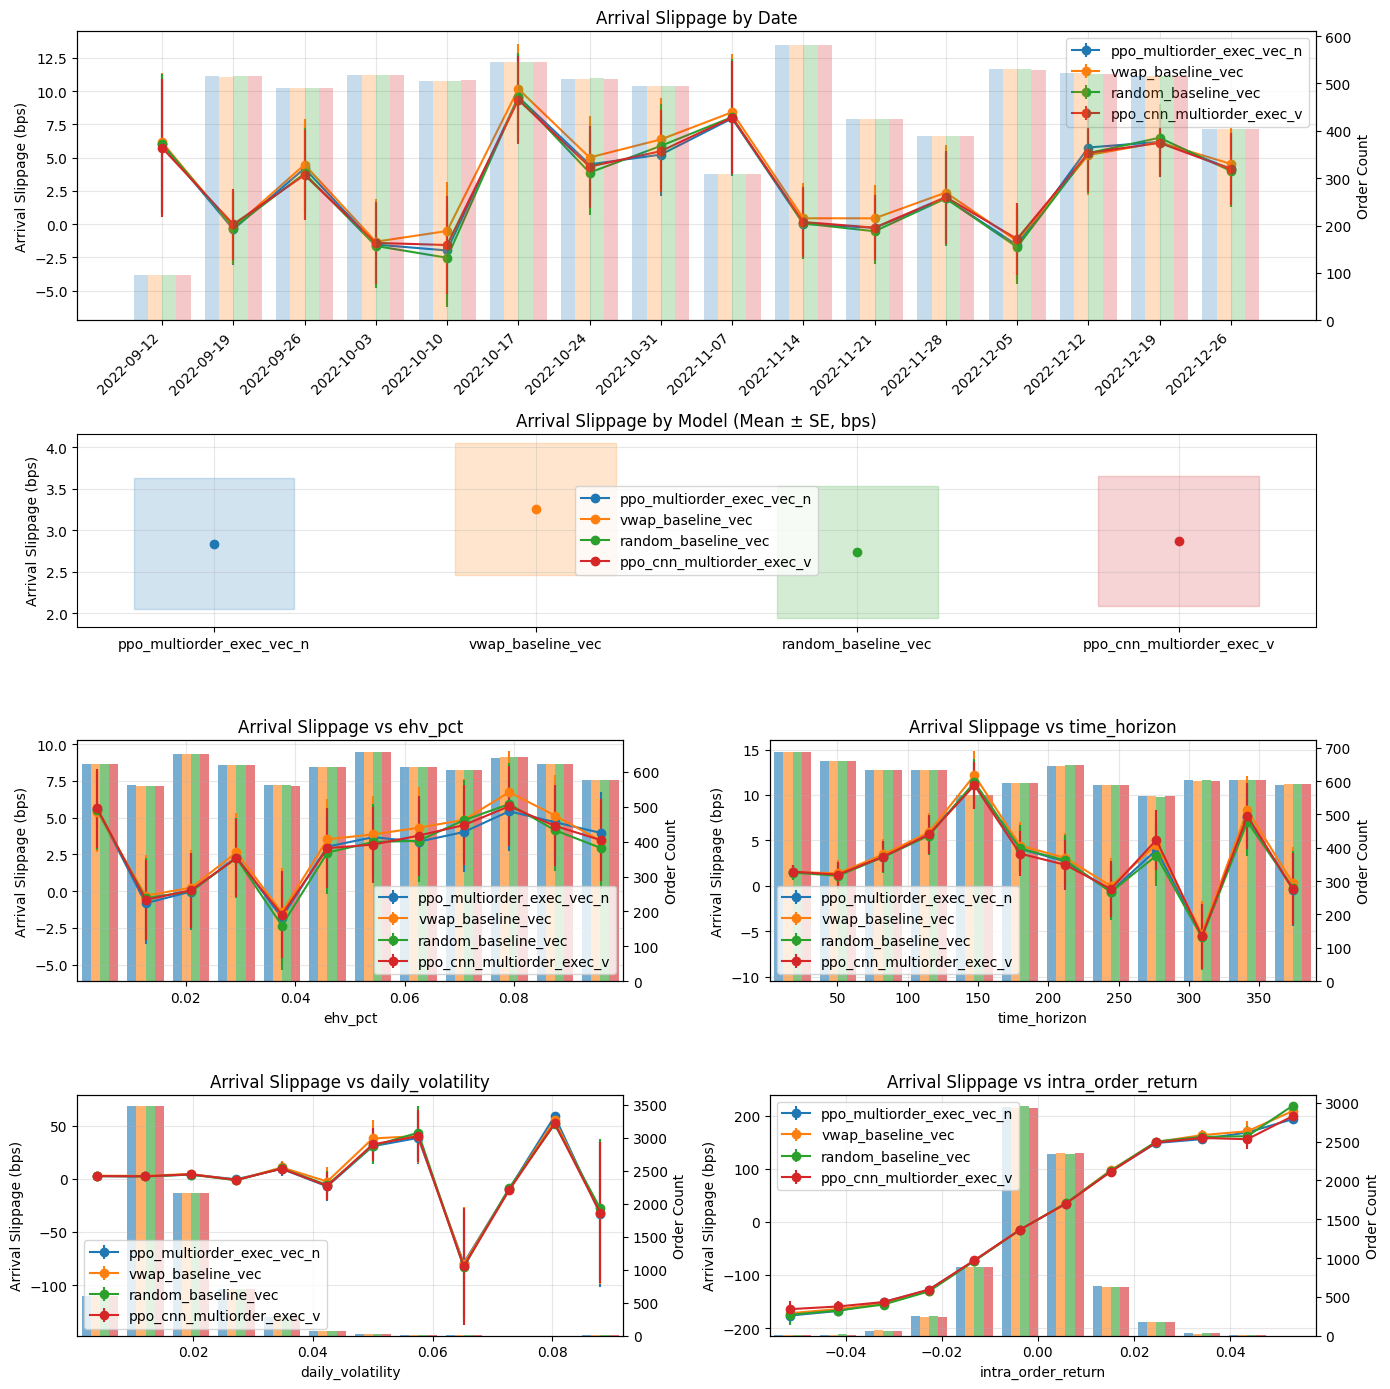

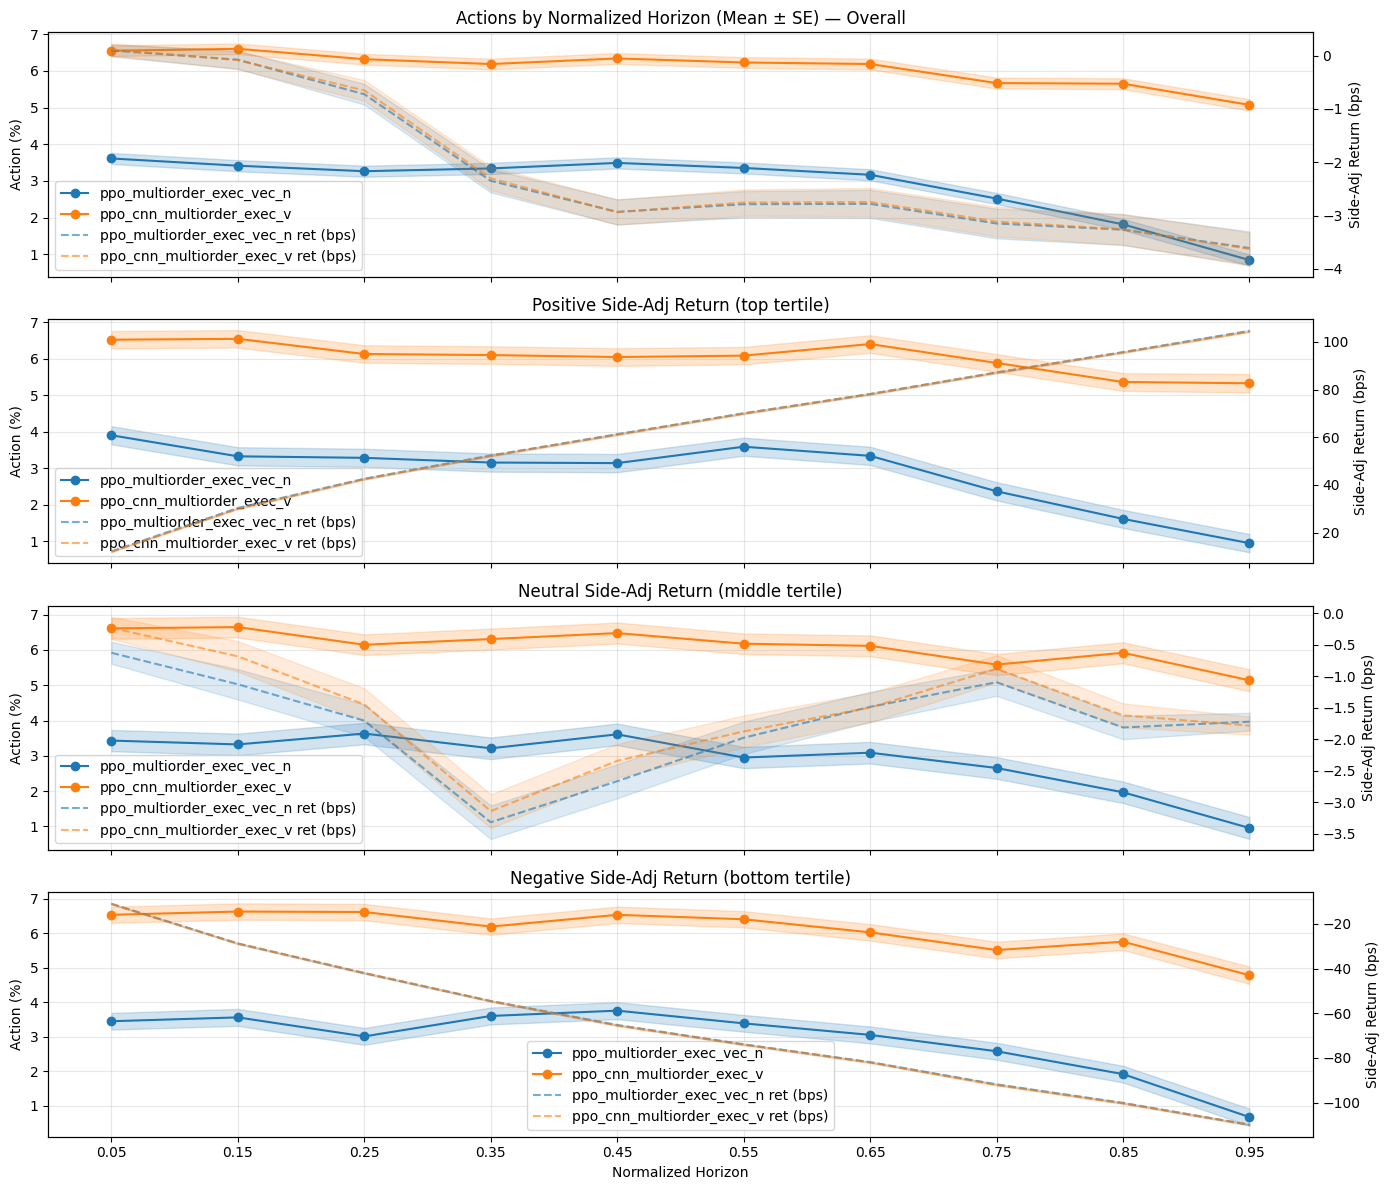


=== Plotting orders for ppo_multiorder_exec_vec_nsteps_2048_batchsize_8192_epochs_3 ===


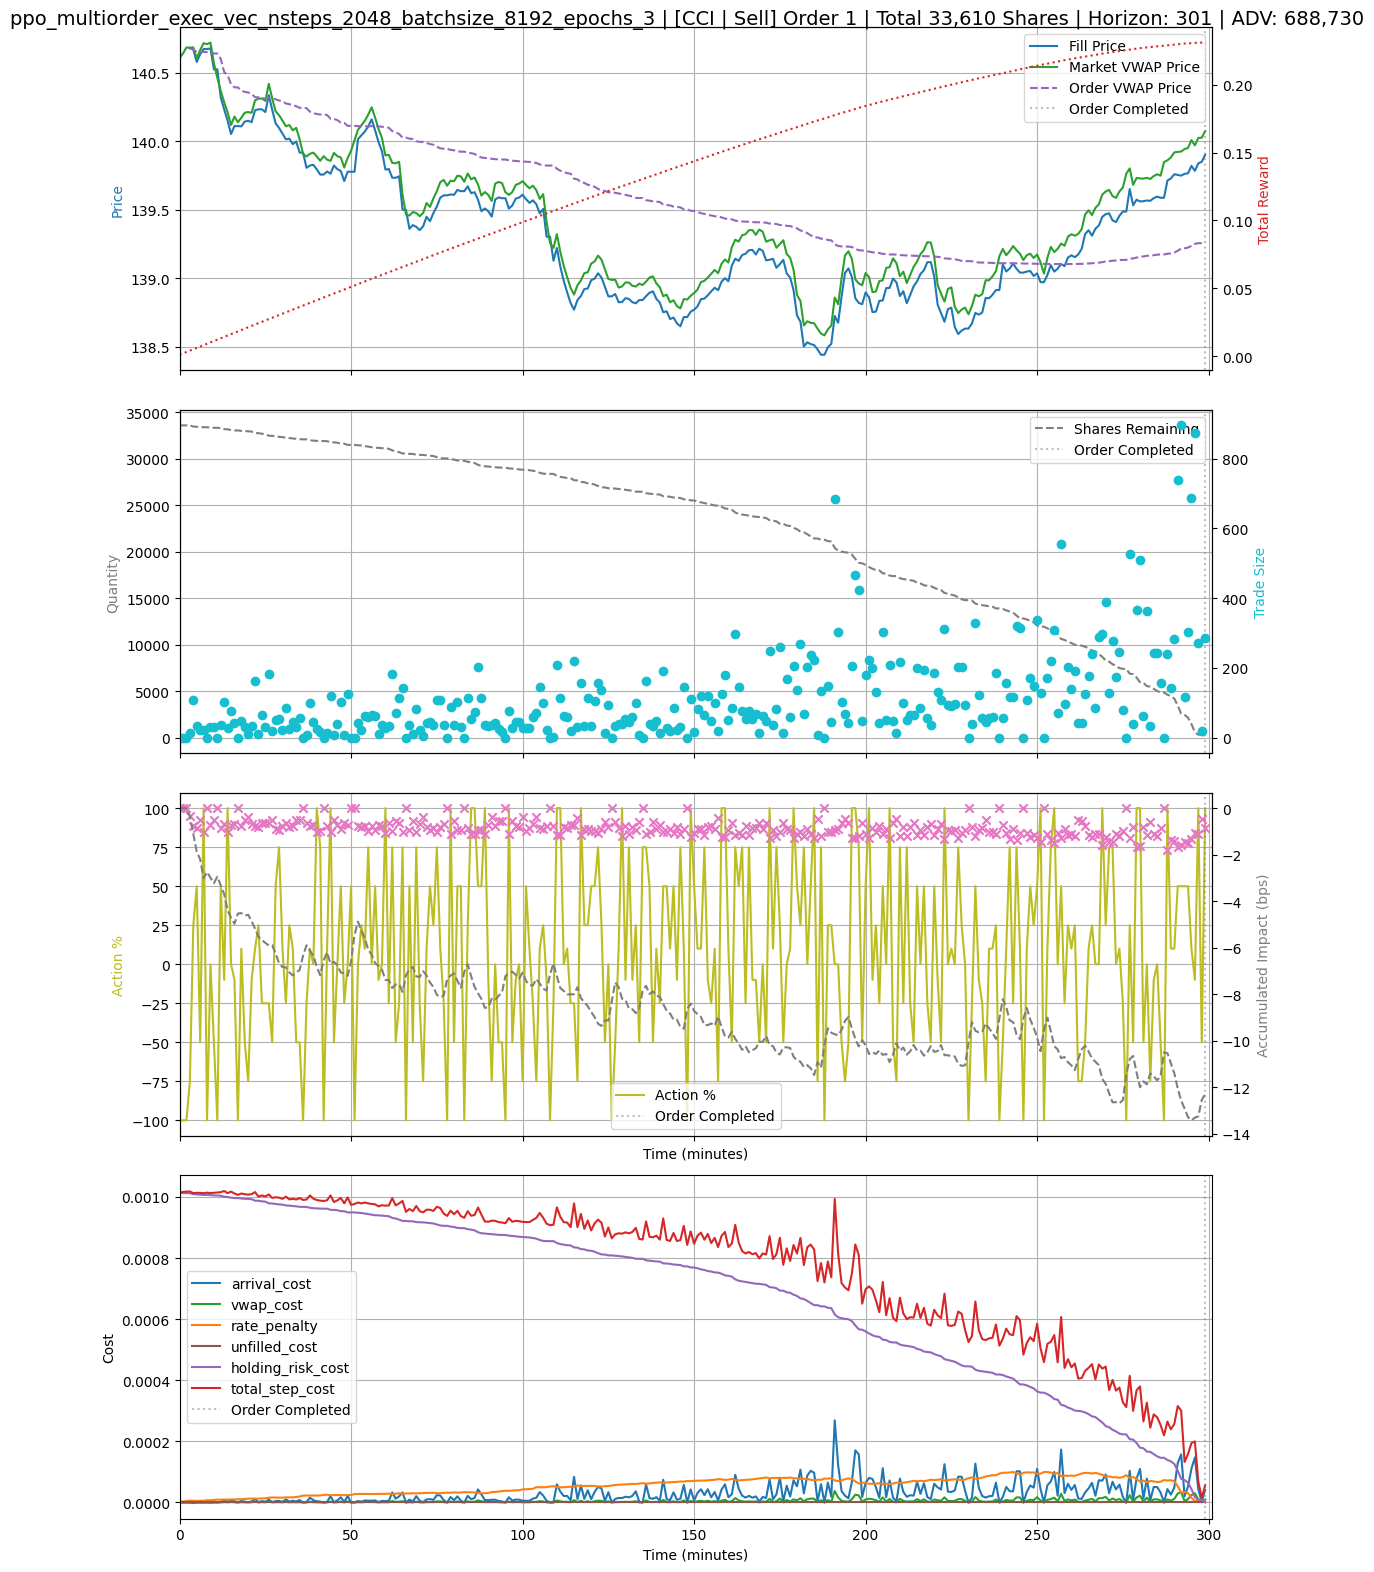

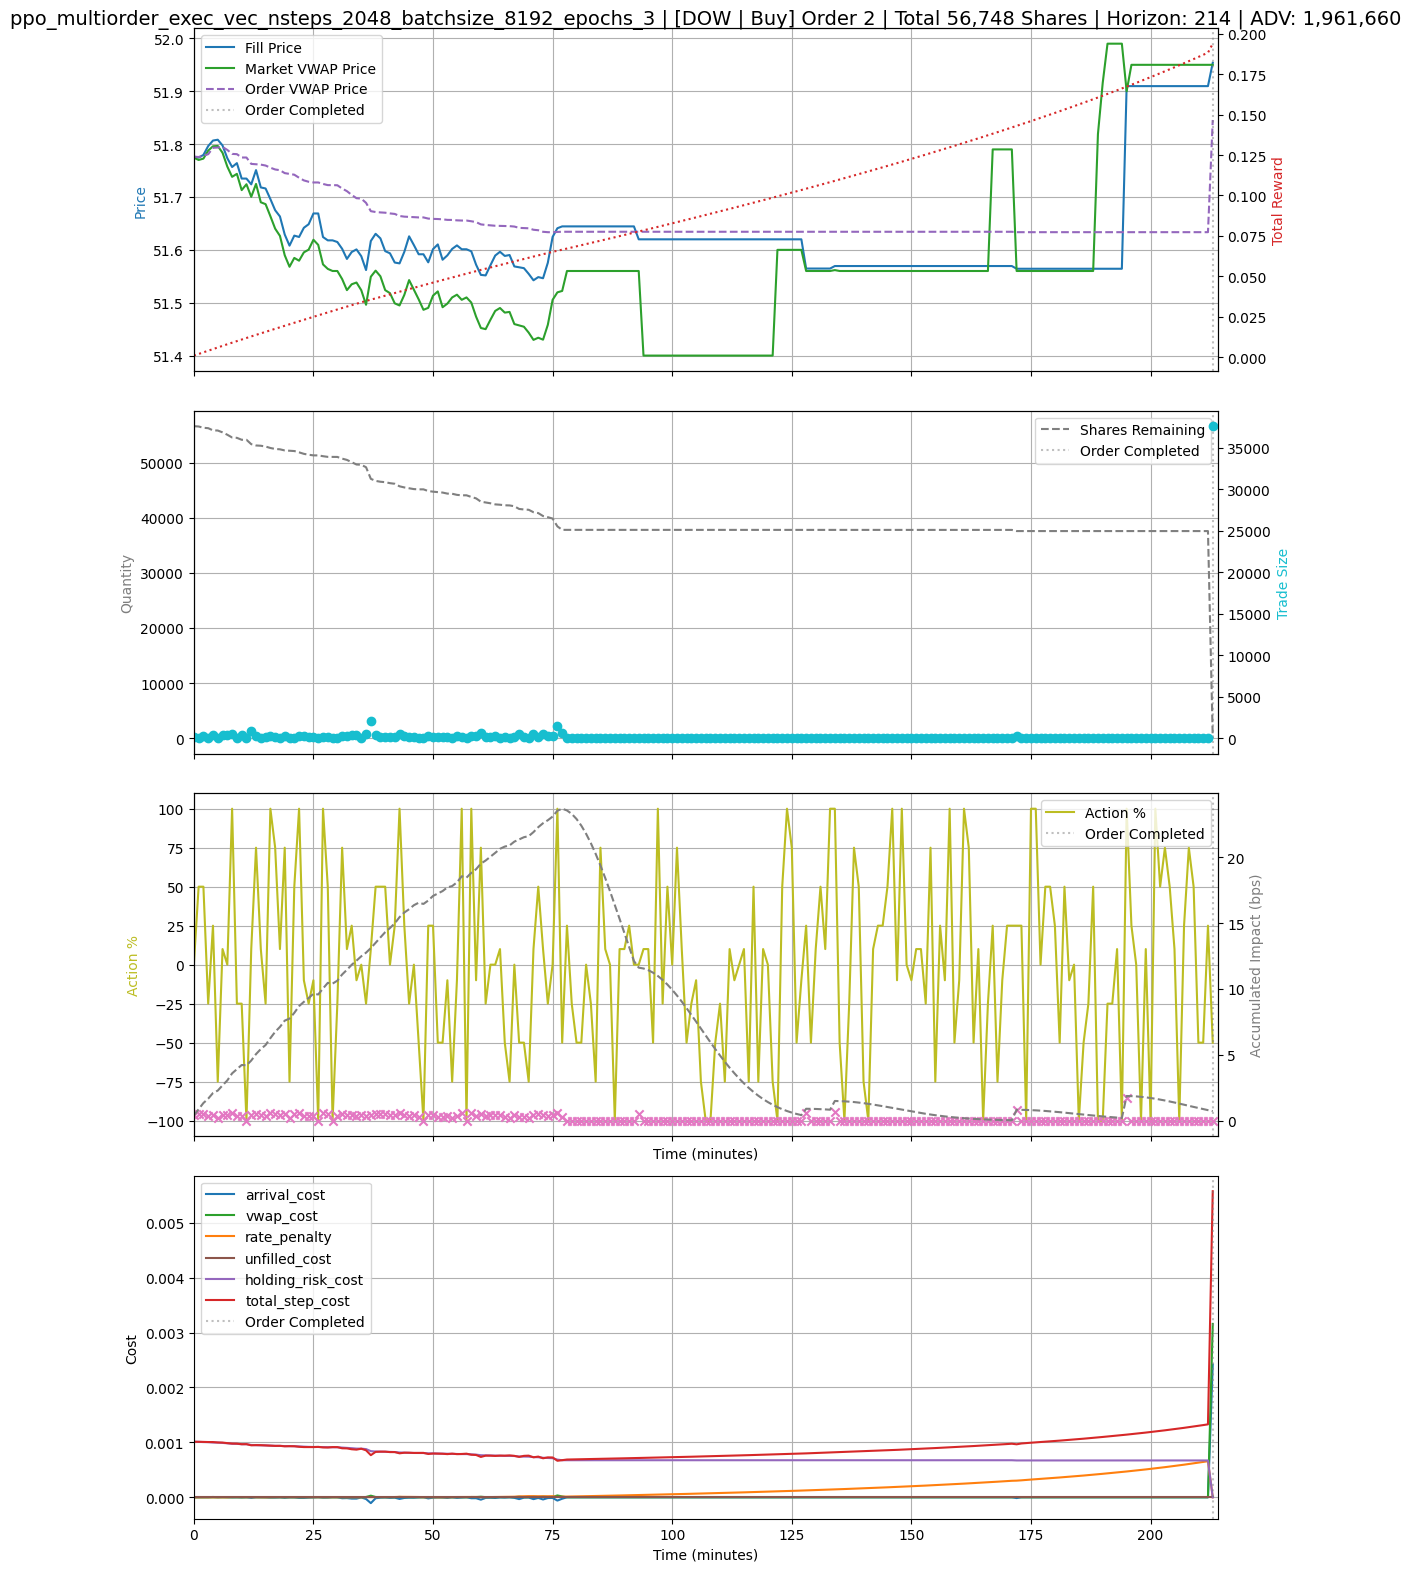

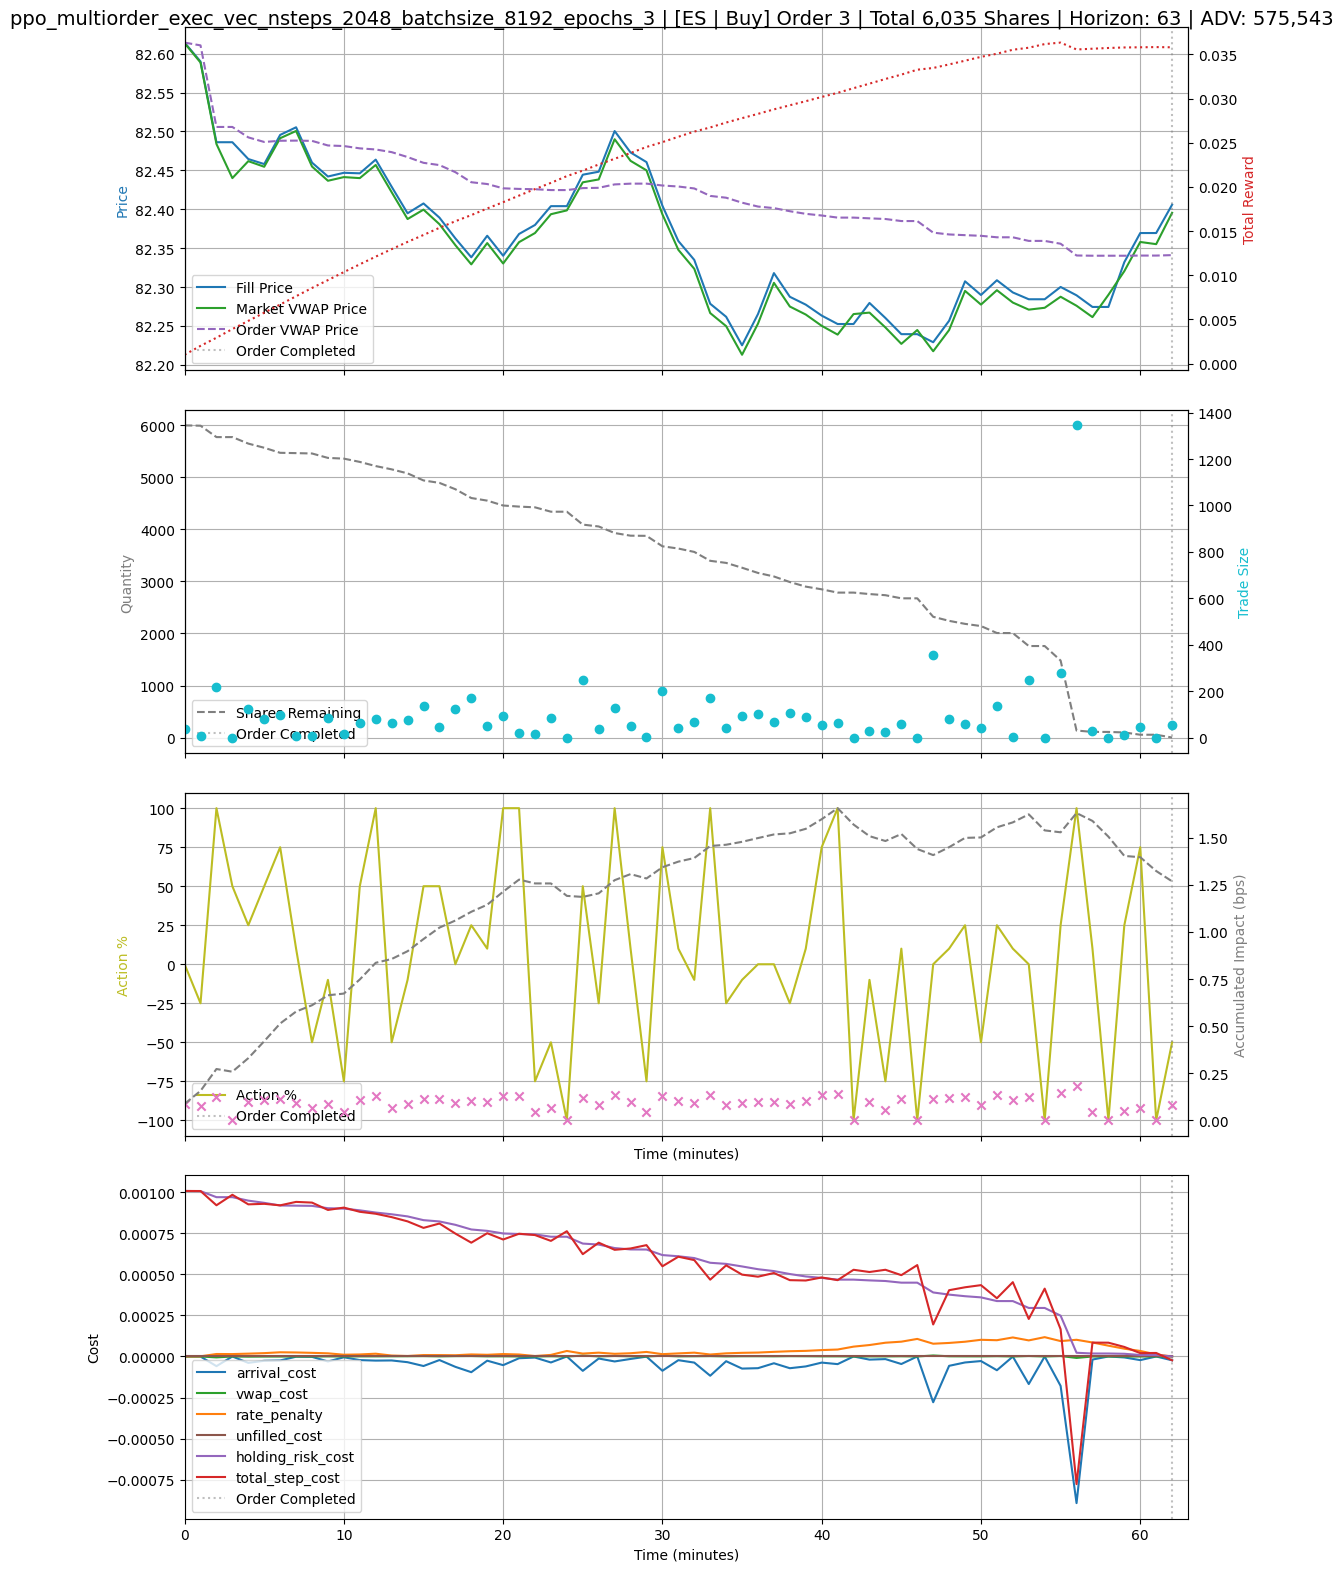


=== Plotting orders for vwap_baseline_vec ===


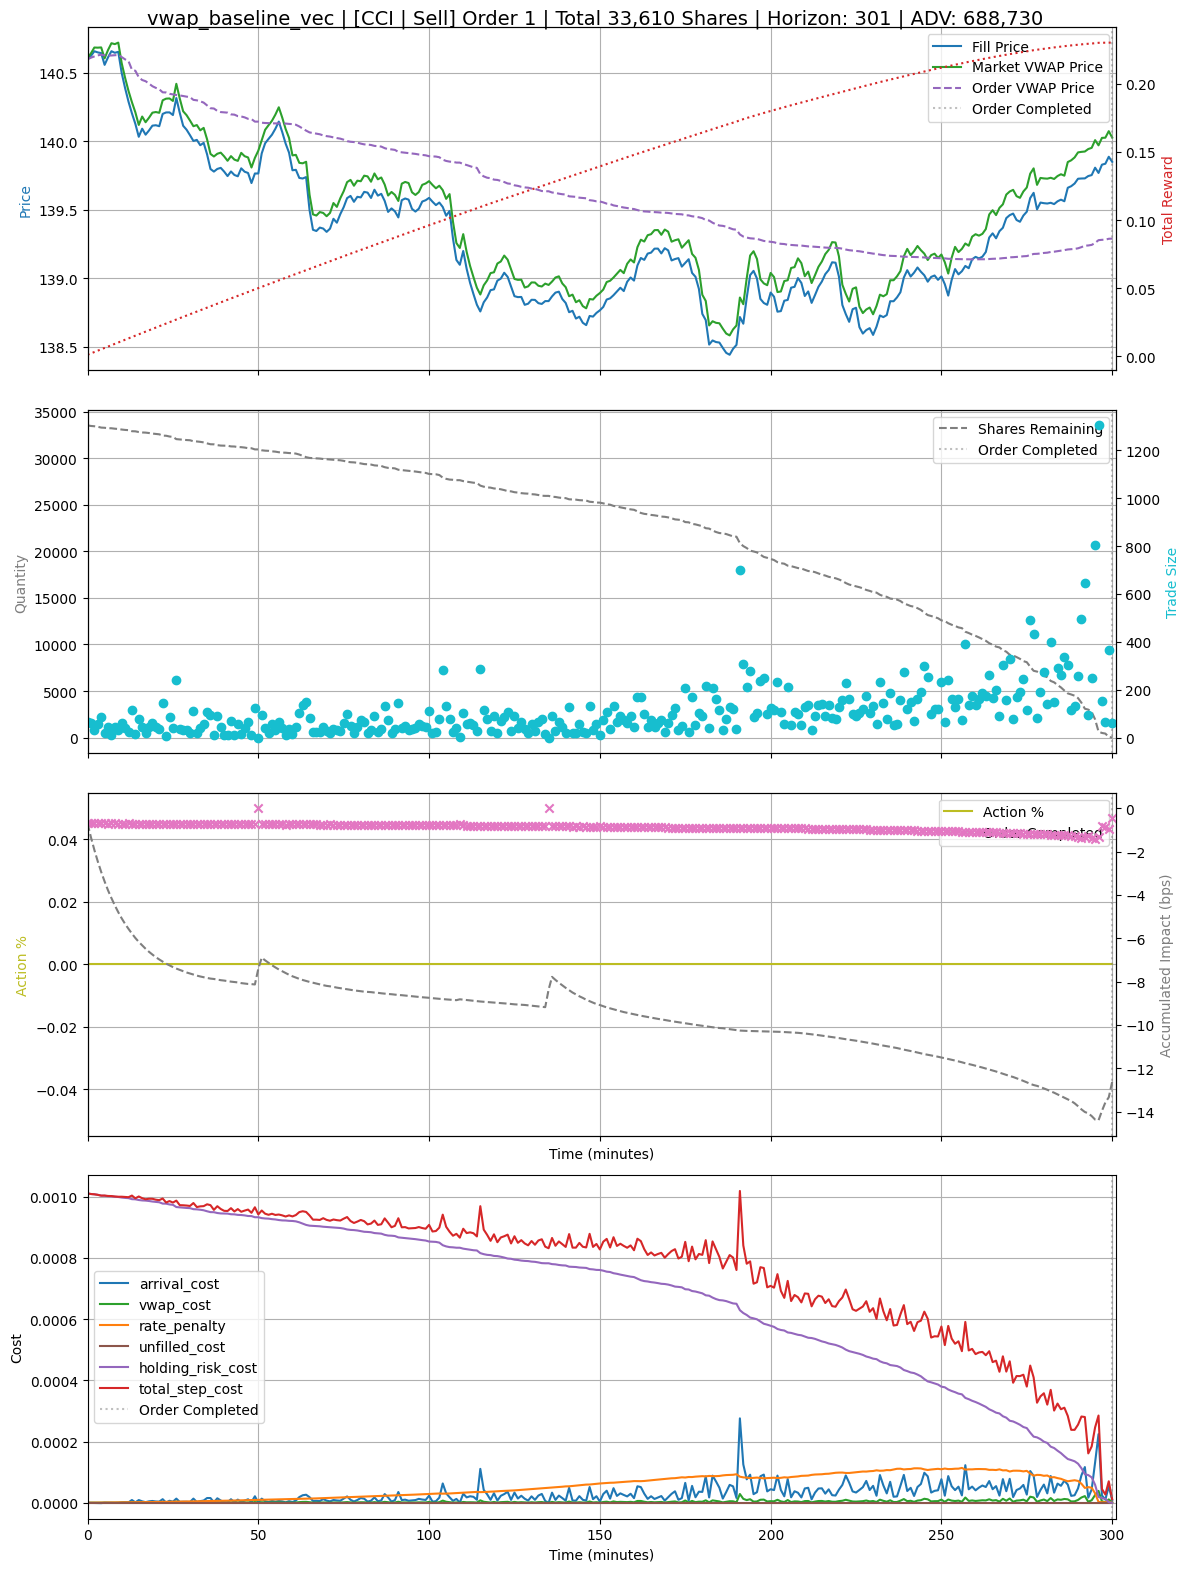

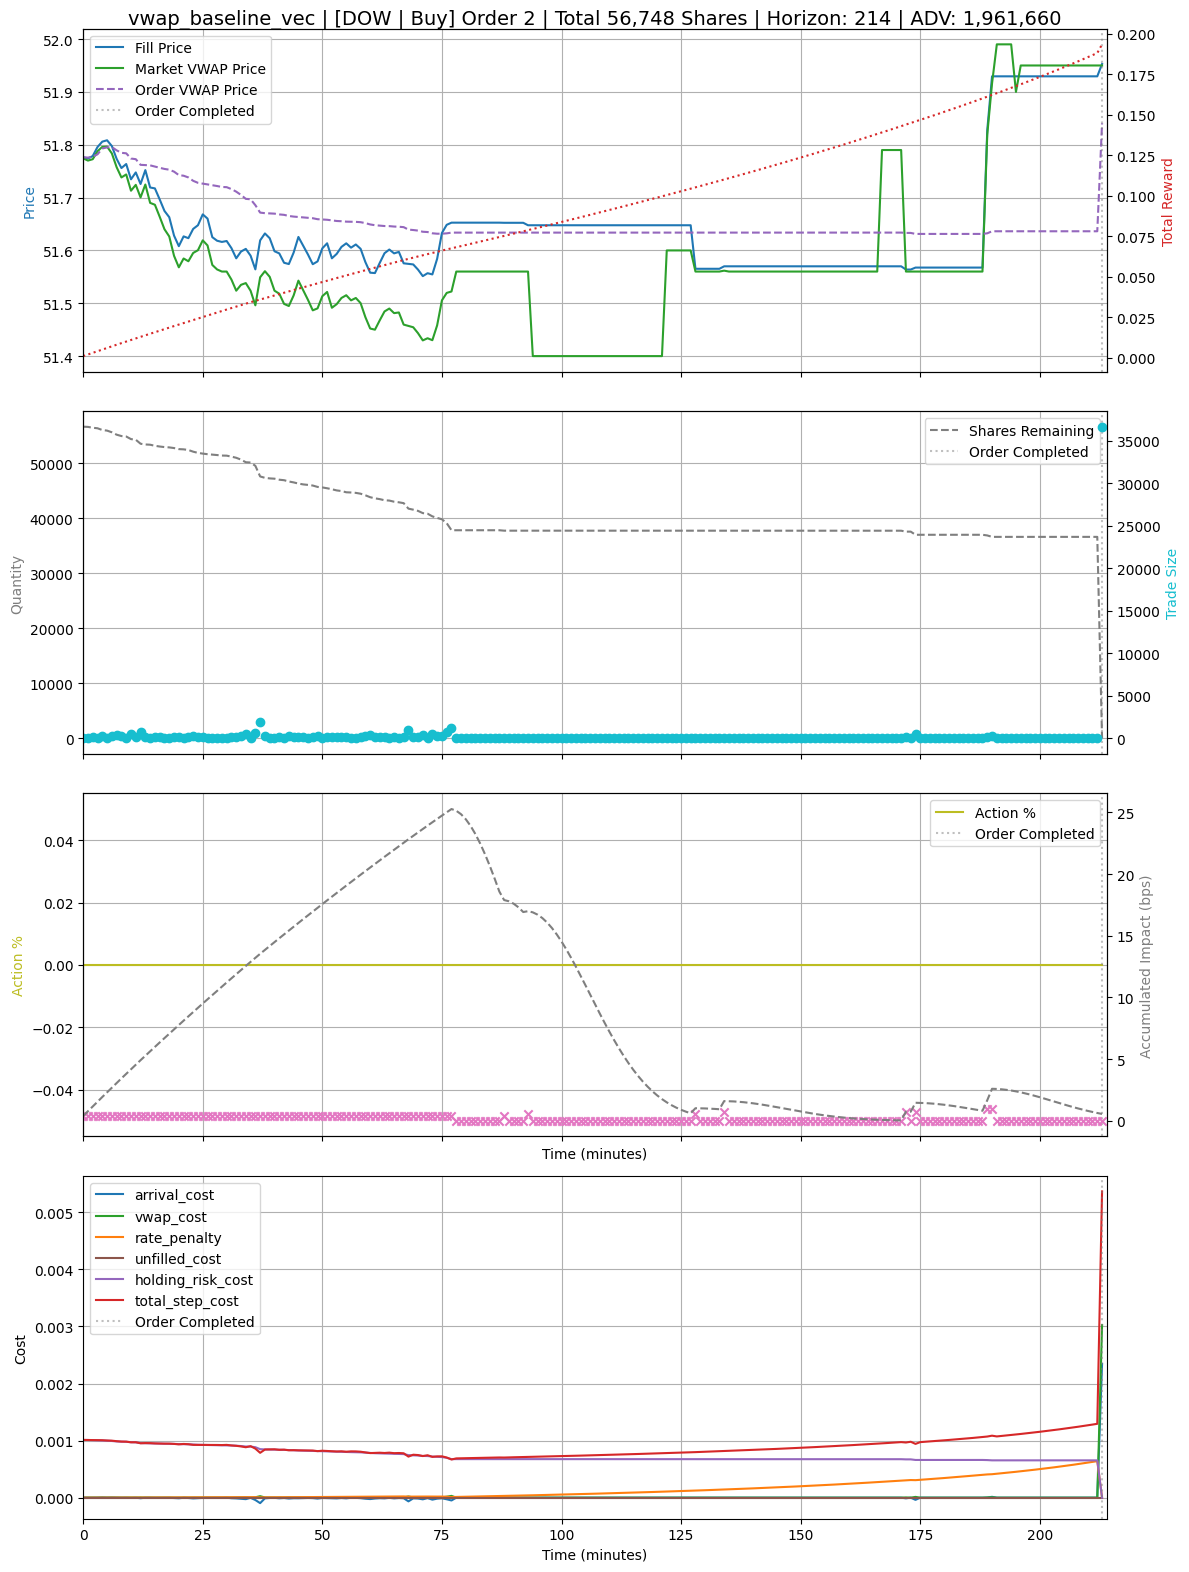

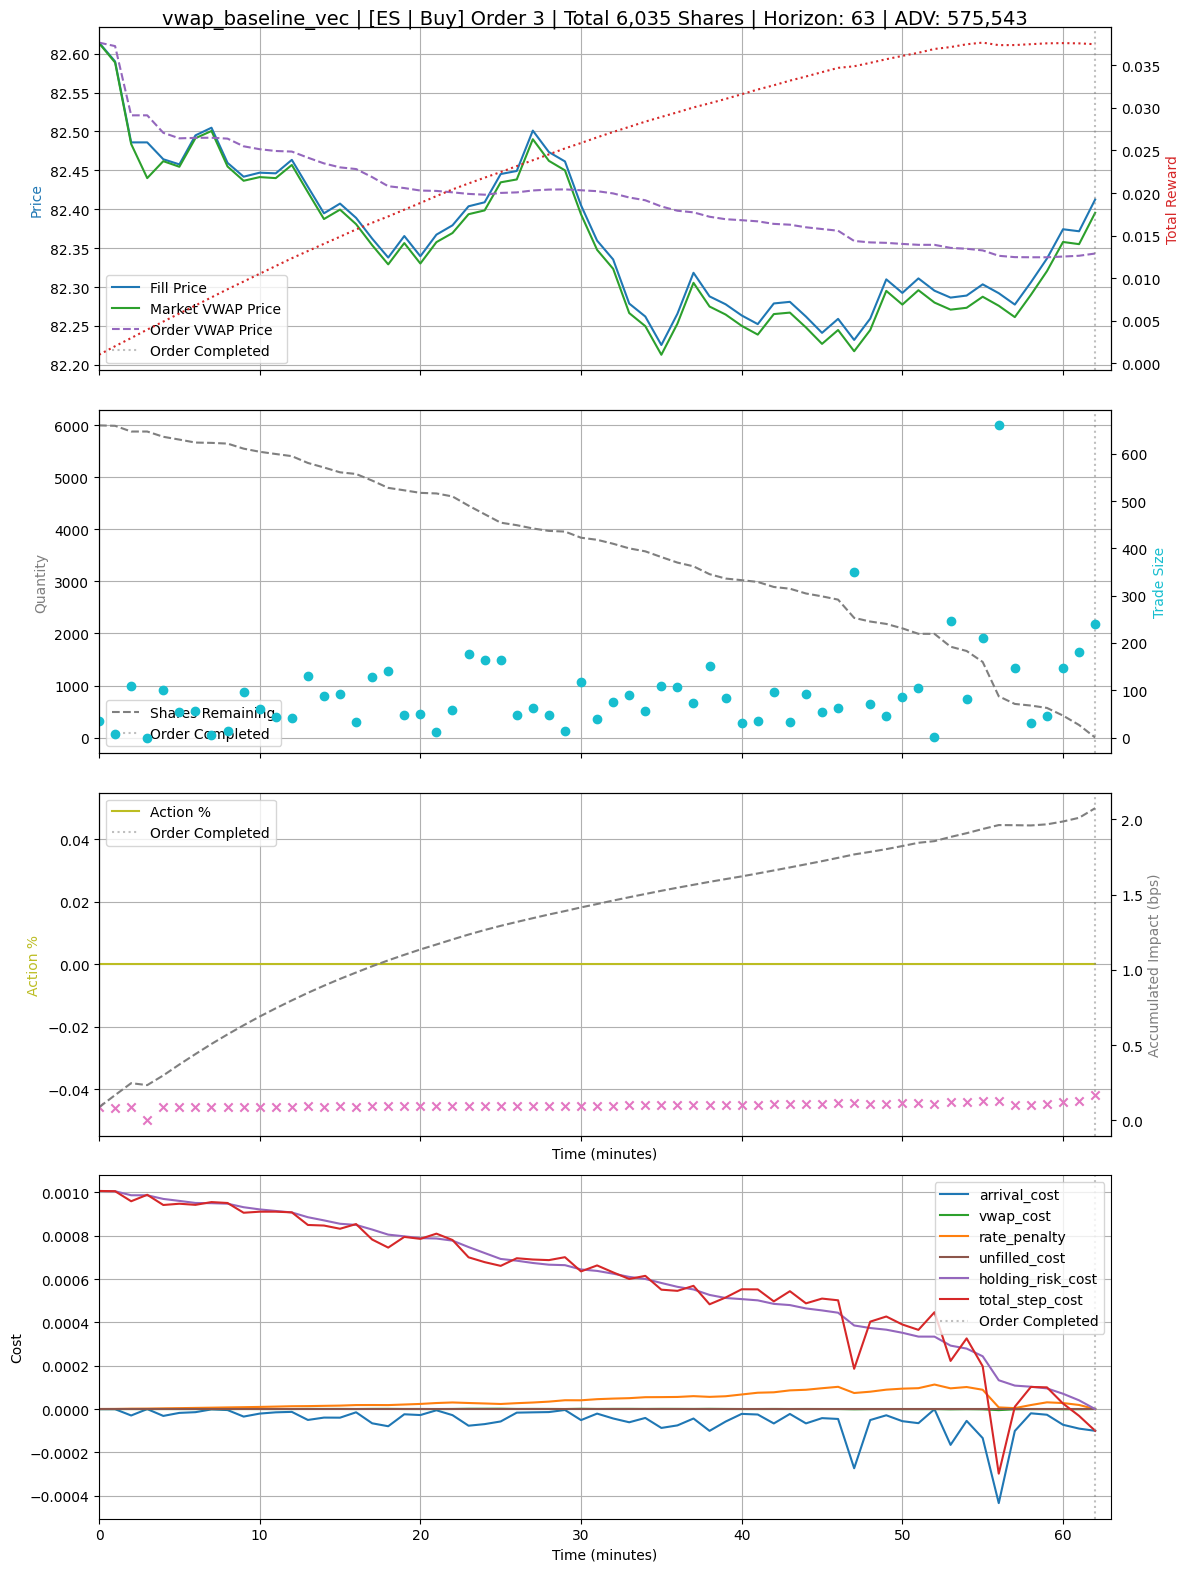


=== Plotting orders for random_baseline_vec ===


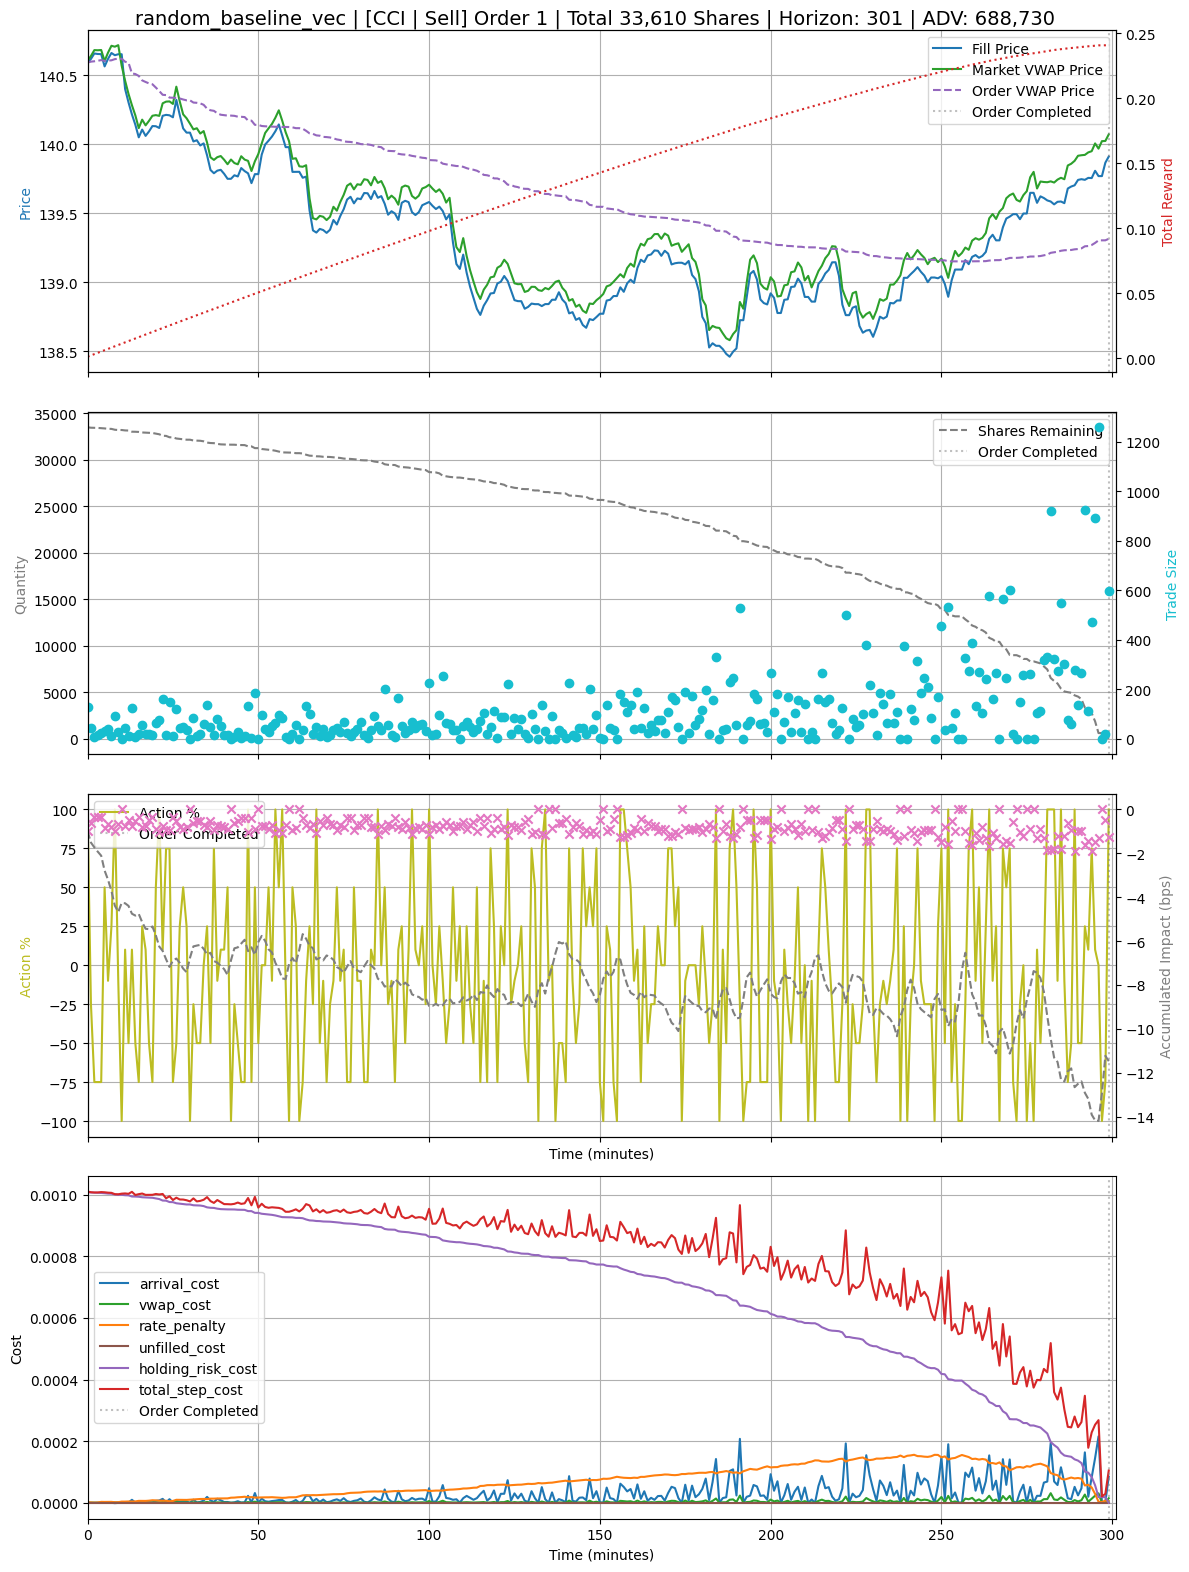

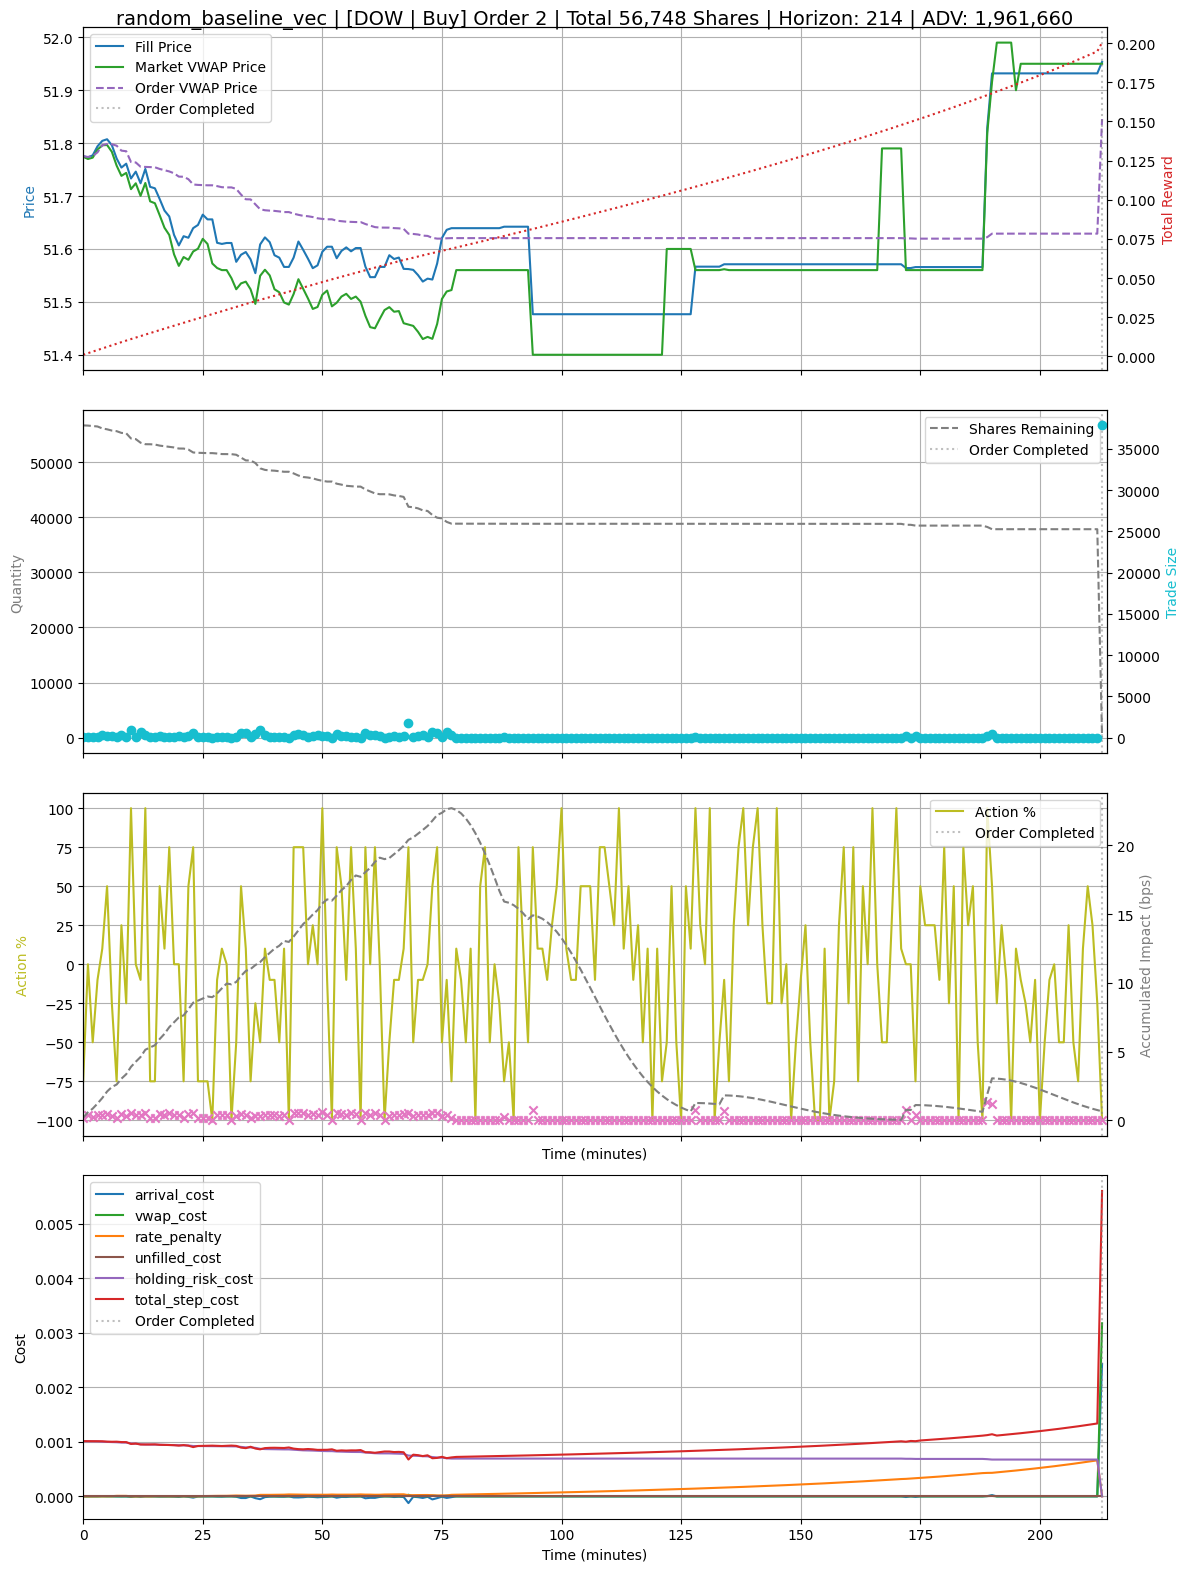

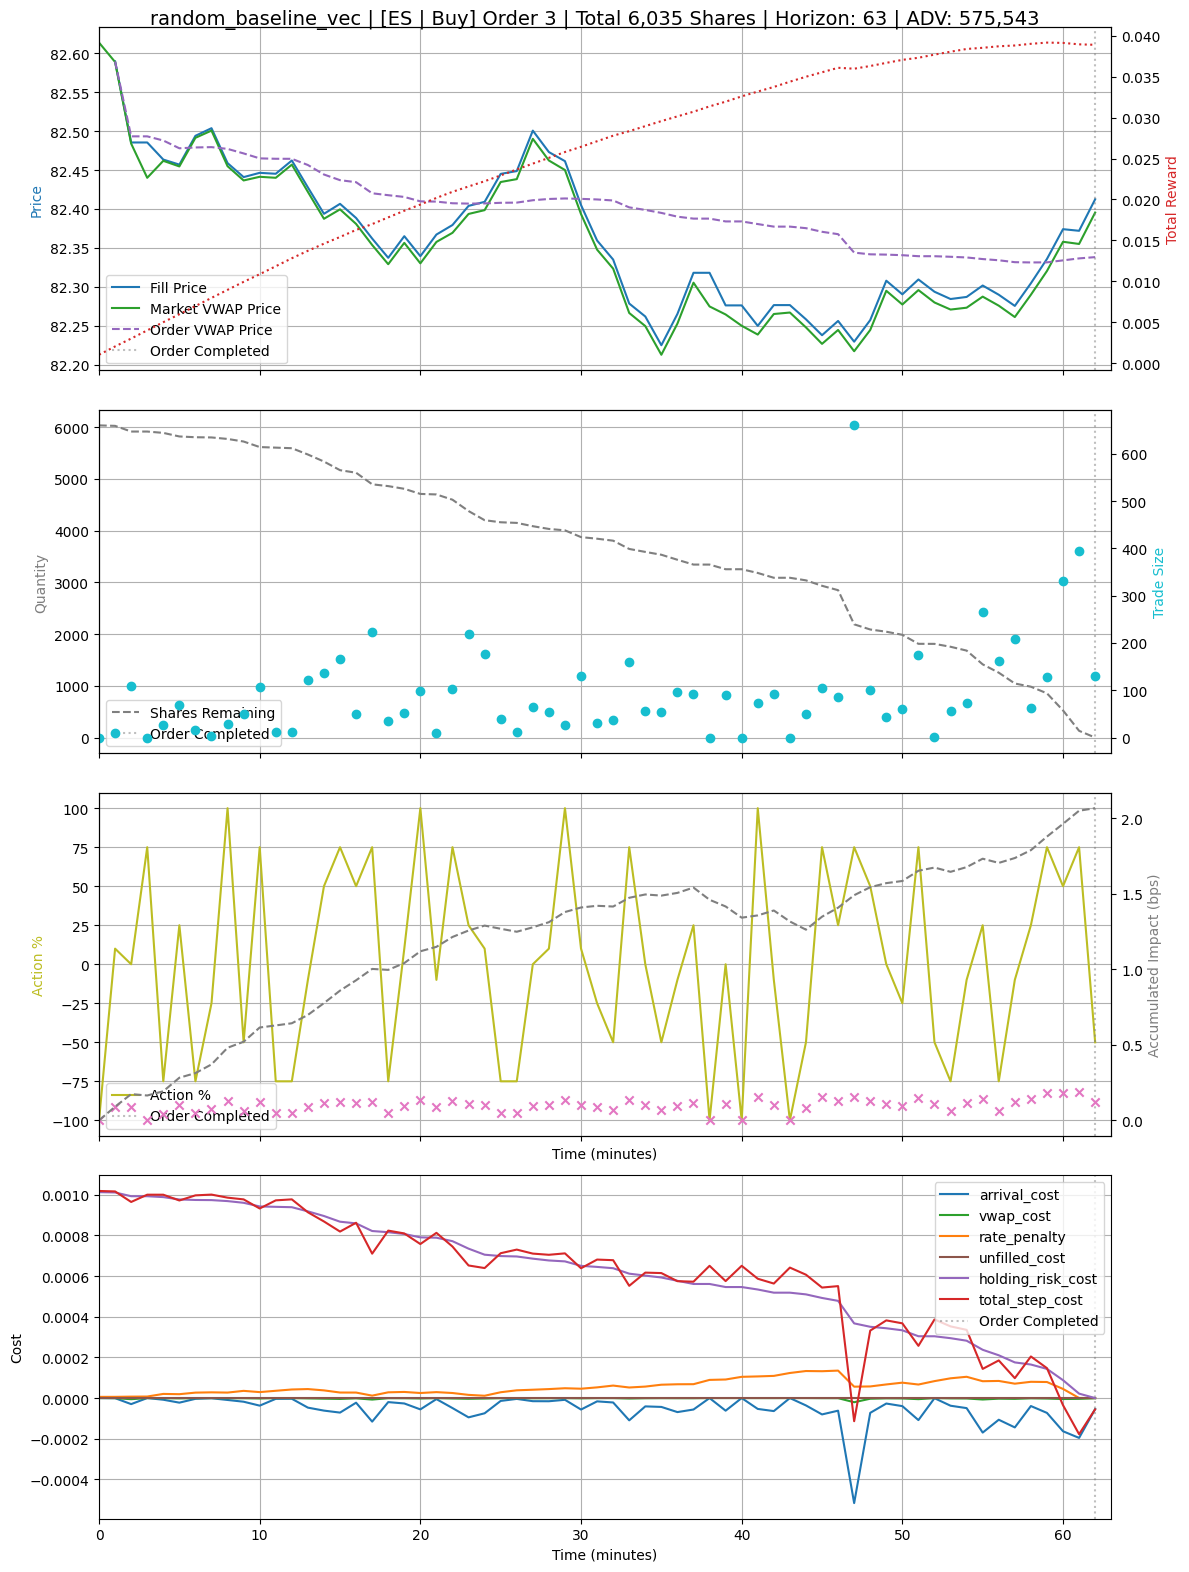


=== Plotting orders for ppo_cnn_multiorder_exec_vec_cpu_nsteps_2048_batchsize_8192_epochs_3 ===


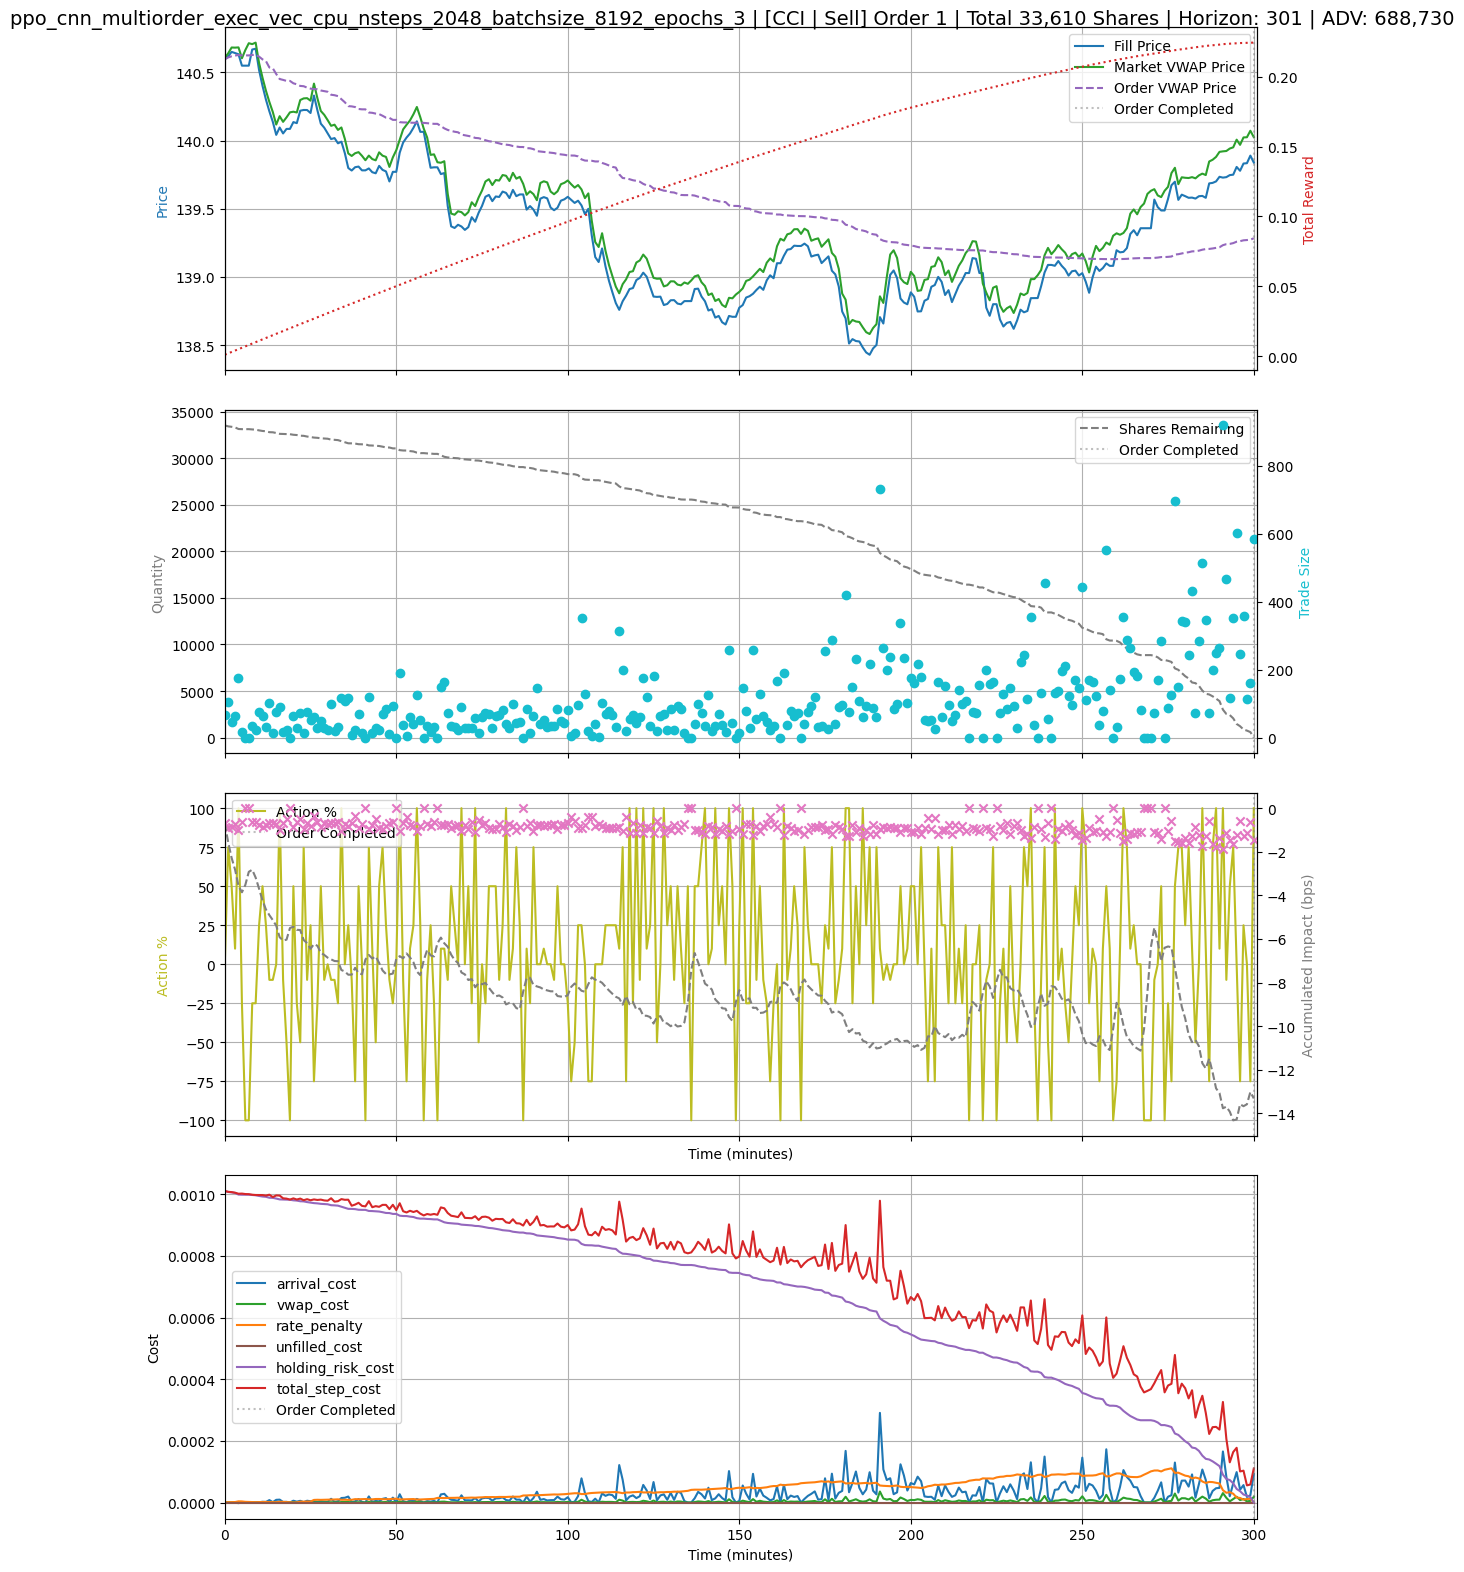

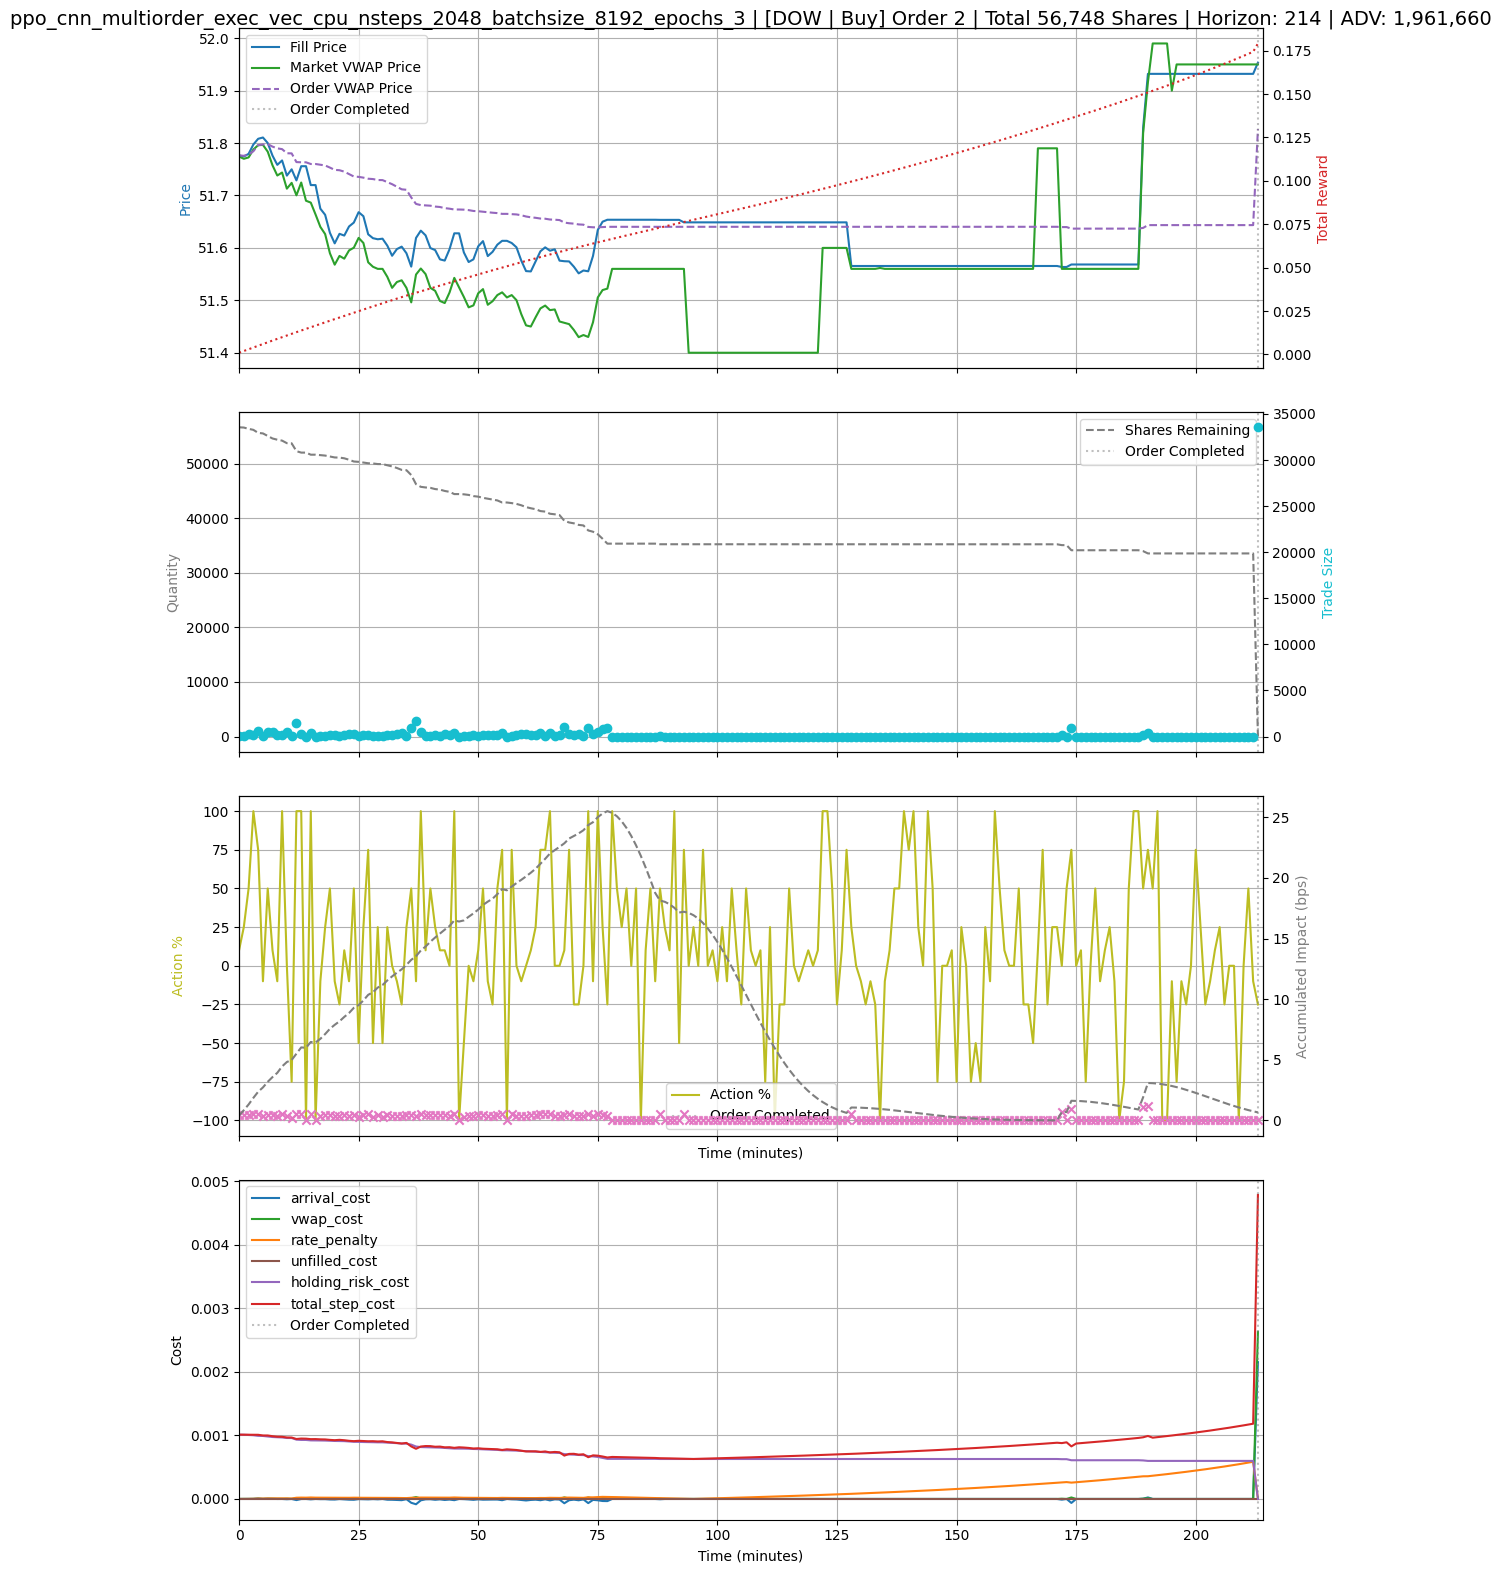

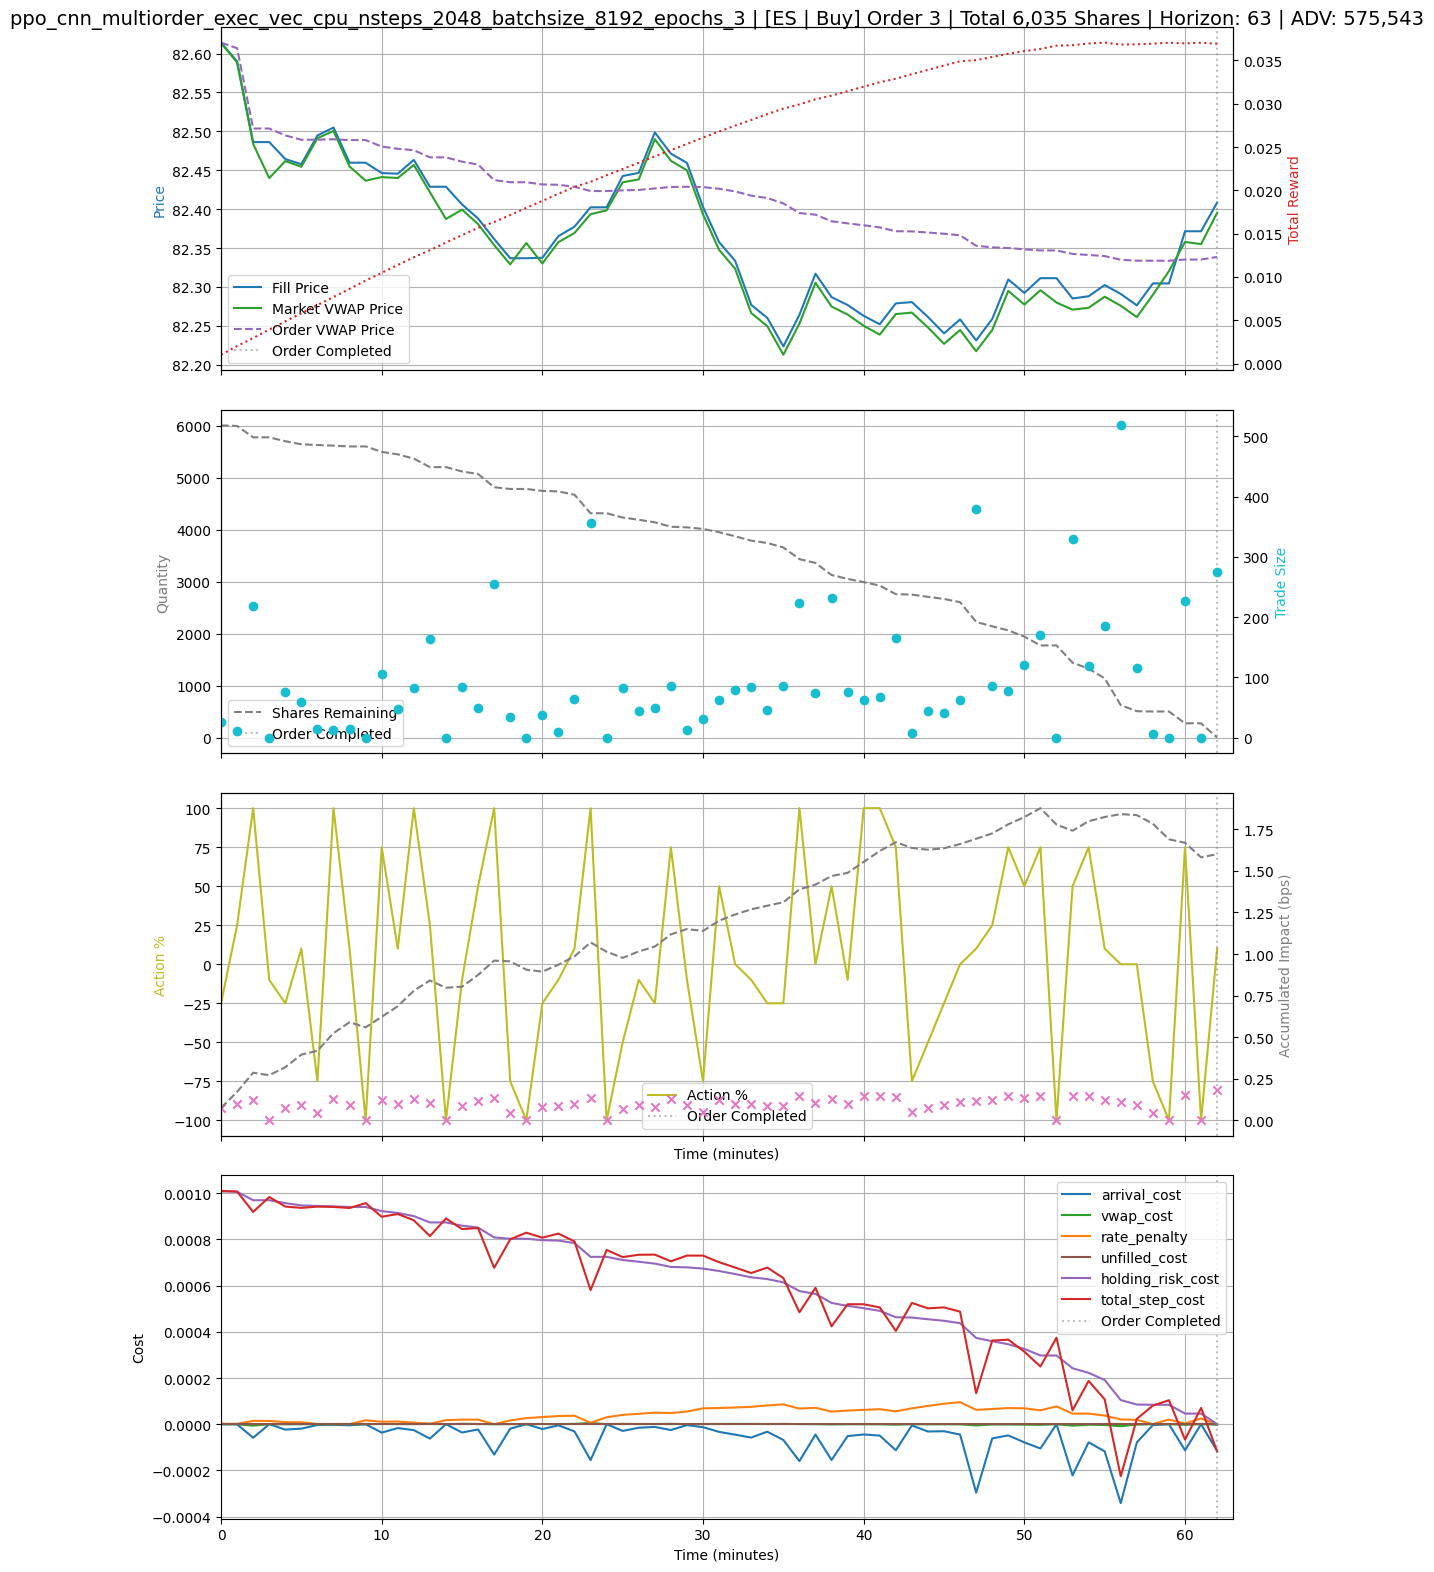


Analysis completed in 29.33 seconds

VECTORIZED PERFORMANCE SUMMARY


NameError: name 'model_name_list' is not defined

In [ ]:

import tca_data_manager as tca
import importlib
import time                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
import pandas as pd
import torch
import psutil


import render_plots as rp

importlib.reload(rp)
import render_plots as rp


# does tcadm exist
try:
    stored_test_orders = tcadm.load_latest()
except:
    print("No TCA data manager found, creating new one")
    tcadm = tca.TCADataManager()
    stored_test_orders = tcadm.load_latest()

# Vectorized plotting and analysis
print("Generating vectorized analysis...")
start_time = time.time()

# Create comprehensive summary tables
print("\nVectorized Test Environment Results:")
print("="*80)
rp.create_execution_summary_and_plots(orders_dict=stored_test_orders)

analysis_time = time.time() - start_time
print(f"\nAnalysis completed in {analysis_time:.2f} seconds")

# Performance comparison and system metrics
print("\nVECTORIZED PERFORMANCE SUMMARY")
print("="*80)

# Calculate performance metrics
total_episodes = len(model_name_list) * num_episodes
total_execution_time = sum(execution_times.values())
avg_time_per_episode = total_execution_time / total_episodes

print(f"Device used: {device}")
print(f"Total models tested: {len(model_name_list)}")
print(f"Episodes per model: {num_episodes}")
print(f"Total episodes executed: {total_episodes}")
print(f"Total execution time: {total_execution_time:.2f} seconds")
print(f"Average time per episode: {avg_time_per_episode:.4f} seconds")
print(f"Episodes per second: {1/avg_time_per_episode:.2f}")

# Memory usage
memory_info = psutil.virtual_memory()
print(f"\nMemory usage:")
print(f"  Total RAM: {memory_info.total / 1e9:.1f} GB")
print(f"  Available RAM: {memory_info.available / 1e9:.1f} GB")
print(f"  Used RAM: {memory_info.used / 1e9:.1f} GB ({memory_info.percent:.1f}%)")

# GPU memory if available
if device == 'cuda':
    gpu_memory = torch.cuda.memory_allocated() / 1e9
    gpu_memory_cached = torch.cuda.memory_reserved() / 1e9
    print(f"\nGPU memory usage:")
    print(f"  Allocated: {gpu_memory:.2f} GB")
    print(f"  Cached: {gpu_memory_cached:.2f} GB")



To-dos:


Comparison and metric:
* Change table to put std on a separate row
* Fix VWAP baseline to use volume profile and execute the full horizon
* Add Almgren-Chriss baseline
* Normalize behaviors across agents, trajectories - actions, price sensitivity
* Create a plot of all statistics across orders (execution statistics)
* add trimming to the rendering function

Training variablility:
* Find and break out days by different regimes, e.g. high volatility, low volatility, trending, mean reverting, shocks, stable markets, etc. add these to the gym


-------------------------------------------------------------------
* Consider more advanced propagator models such as the 6-event propagator model (ch. 14 of Trades, Quotes and Prices)
* Implement multiple agents from papers and using Quality Diveristy and MAP methods
* Linear versus square root for 1 minute impact?

* Make volume profiles to scale volume and remove auctions, remove special days
* TODO: fix warnings in generate orders
* TODO: refactor optimal execuion env


**Future Vectorized Optimizations**

To-dos for enhanced vectorized performance:

**Environment Optimizations:**
* Implement true multi-GPU support for larger scale training
* Add mixed precision training for faster convergence
* Implement gradient accumulation for larger effective batch sizes
* Add distributed training support

**Model Optimizations:**
* Implement model quantization for faster inference
* Add model pruning for memory efficiency
* Explore transformer-based architectures
* Implement ensemble methods with vectorized prediction

**Data Pipeline Optimizations:**
* Implement data streaming for larger datasets
* Add data preprocessing on GPU
* Implement efficient data caching
* Add real-time data integration

**Analysis Optimizations:**
* Vectorized metric computation
* GPU-accelerated visualization
* Parallel backtesting framework
* Real-time performance monitoring

The vectorized implementation demonstrates significant performance gains while maintaining the same core functionality and research objectives.
